In [1]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import numpy as np
import os
import pandas as pd
from pathlib import Path
from scipy import stats
import seaborn as sns

In [2]:
sns.set_theme(style="whitegrid", font_scale=1.1)

# Load Data

In [102]:
# CPI: https://www.minneapolisfed.org/about-us/monetary-policy/inflation-calculator/consumer-price-index-1913-
cpi_map = {
    2013: 233,
    2014: 236.7,
    2015: 237,
    2016: 240,
    2017: 245.1,
    2018: 251.1,
    2019: 255.7,
    2020: 258.8,
    2021: 271,
    2022: 292.7,
    2023: 304.7,
    2024: 313.7,
    2025: 322.3
}

In [103]:
pain_cpt = {
    "facet_blocks": ["64490", "64493"], # "64491", "64492",  "64495"
    "facet_rfa": ["64633", "64634", "64635", "64636"],
    "transforaminal_esi": ["64483"], # "64484"
    "interlaminar_caudal_esi": ["62320", "62321", "62322", "62323"],
    "si_joint_rfa": ["64628"], # , "64629"
    "vertebral_augmentation": ["22510", "22511", "22512"], # , "22513", "22514", "22515"
    "other_spine_interventions": ["62287", "0275T"]
}

cpt_map = {}

for category, codes in pain_cpt.items():
    for code in codes:
        try:
            cpt_map[int(code)] = category
            cpt_map[code] = category
        except:
            cpt_map[code] = category

In [132]:
pain_cpt

{'facet_blocks': ['64490', '64493'],
 'facet_rfa': ['64633', '64634', '64635', '64636'],
 'transforaminal_esi': ['64483'],
 'interlaminar_caudal_esi': ['62320', '62321', '62322', '62323'],
 'si_joint_rfa': ['64628'],
 'vertebral_augmentation': ['22510', '22511', '22512'],
 'other_spine_interventions': ['62287', '0275T']}

In [104]:
current_dir = os.getcwd()

In [105]:
surg_data = pd.read_csv(os.path.join(current_dir, "processed-data", "surg_pain_cpt_processed.csv"))
nonsurg_data = pd.read_csv(os.path.join(current_dir, "processed-data", "nonsurg_pain_cpt_processed.csv"))

# Analysis

In [106]:
for df in [surg_data, nonsurg_data]:
    df['CPI'] = df['year'].map(cpi_map).fillna(0)
    
    # Adjusted amounts
    df['Avg_Mdcr_Stdzd_Amt_adj'] = df['Avg_Mdcr_Stdzd_Amt'] / df['CPI'] * cpi_map[2023]
    df['Avg_Mdcr_Pymt_Amt_adj'] = df['Avg_Mdcr_Pymt_Amt'] / df['CPI'] * cpi_map[2023]

    # Raw amounts summed over services per provider
    df['Tot_Srvcs_Spend'] = df['Tot_Srvcs'] * df['Avg_Mdcr_Stdzd_Amt'] 
    df['Tot_Pymt'] = df['Tot_Srvcs'] * df['Avg_Mdcr_Pymt_Amt'] 

    # Raw amounts summed over services per provider, adjusted
    df['Tot_Srvcs_Spend_adj'] = df['Tot_Srvcs'] * df['Avg_Mdcr_Stdzd_Amt_adj'] 
    df['Tot_Pymt_adj'] = df['Tot_Srvcs'] * df['Avg_Mdcr_Pymt_Amt_adj'] 

In [107]:
surg_data = surg_data[["HCPCS_Cd", "Rndrng_NPI", "Tot_Srvcs", "Avg_Mdcr_Stdzd_Amt", "Avg_Mdcr_Pymt_Amt", "Tot_Srvcs_Spend", "Tot_Pymt", "Avg_Mdcr_Stdzd_Amt_adj", "Avg_Mdcr_Pymt_Amt_adj", "Tot_Srvcs_Spend_adj", "Tot_Pymt_adj", "year"]]
nonsurg_data = nonsurg_data[["HCPCS_Cd", "Rndrng_NPI", "Tot_Srvcs", "Avg_Mdcr_Stdzd_Amt", "Avg_Mdcr_Pymt_Amt",  "Tot_Srvcs_Spend", "Tot_Pymt", "Avg_Mdcr_Stdzd_Amt_adj", "Avg_Mdcr_Pymt_Amt_adj", "Tot_Srvcs_Spend_adj", "Tot_Pymt_adj", "year"]]

In [108]:
for data in [surg_data, nonsurg_data]:
    data['procedure'] = data['HCPCS_Cd'].map(cpt_map)

/var/folders/jv/hvl4bxhn45d10f4fq__lhlxm0000gn/T/ipykernel_57424/763500830.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['procedure'] = data['HCPCS_Cd'].map(cpt_map)


In [109]:
groupby_key = 'procedure'
specialty_name = ["Surgical", "Nonsurgical"]

In [110]:
# Group by procedure and year, and summarize
util_2023_2013_adj_surg = (
    surg_data
    .groupby([groupby_key, 'year'], as_index=False)
    .agg(
        Sum_Utilization=('Tot_Srvcs', 'sum'),
        Sum_Spend=('Tot_Srvcs_Spend', 'sum'),
        Sum_Pymt=('Tot_Pymt', 'sum'),
        Sum_Spend_adj=('Tot_Srvcs_Spend_adj', 'sum'),
        Sum_Pymt_adj=('Tot_Pymt_adj', 'sum'),
        Avg_Price_per_service_adj=('Avg_Mdcr_Stdzd_Amt_adj', 'mean'),
        Avg_Price_per_service_adj_sem=('Avg_Mdcr_Stdzd_Amt_adj', lambda x: np.std(x, ddof=1) / np.sqrt(len(x))),
        Tot_Pymt_adj=('Tot_Pymt_adj', 'mean'), # Tot_Pymt is actually Avg_Pymt, bad naming
        Tot_Pymt_adj_sem=('Tot_Pymt_adj', lambda x: np.std(x, ddof=1) / np.sqrt(len(x))),
        Sum_Provider=('Rndrng_NPI', lambda x: x.nunique())
    )
)

util_2023_2013_adj_nonsurg = (
    nonsurg_data
    .groupby([groupby_key, 'year'], as_index=False)
    .agg(
        Sum_Utilization=('Tot_Srvcs', 'sum'),
        Sum_Spend=('Tot_Srvcs_Spend', 'sum'),
        Sum_Pymt=('Tot_Pymt', 'sum'),
        Sum_Spend_adj=('Tot_Srvcs_Spend_adj', 'sum'),
        Sum_Pymt_adj=('Tot_Pymt_adj', 'sum'),
        Avg_Price_per_service_adj=('Avg_Mdcr_Stdzd_Amt_adj', 'mean'),
        Avg_Price_per_service_adj_sem=('Avg_Mdcr_Stdzd_Amt_adj', lambda x: np.std(x, ddof=1) / np.sqrt(len(x))),
        Tot_Pymt_adj=('Tot_Pymt_adj', 'mean'), # Tot_Pymt is actually Avg_Pymt, bad naming
        Tot_Pymt_adj_sem=('Tot_Pymt_adj', lambda x: np.std(x, ddof=1) / np.sqrt(len(x))),
        Sum_Provider=('Rndrng_NPI', lambda x: x.nunique()))
)

In [111]:
# Group by procedure and year, and summarize
util_2023_2013_adj_surg_by_cpt = (
    surg_data
    .groupby(['HCPCS_Cd', 'year'], as_index=False)
    .agg(
        Sum_Utilization=('Tot_Srvcs', 'sum'),
        Sum_Spend=('Tot_Srvcs_Spend', 'sum'),
        Sum_Pymt=('Tot_Pymt', 'sum'),
        Sum_Spend_adj=('Tot_Srvcs_Spend_adj', 'sum'),
        Sum_Pymt_adj=('Tot_Pymt_adj', 'sum'),
        Avg_Price_per_service_adj=('Avg_Mdcr_Stdzd_Amt_adj', 'mean'),
        Avg_Price_per_service_adj_sem=('Avg_Mdcr_Stdzd_Amt_adj', lambda x: np.std(x, ddof=1) / np.sqrt(len(x))),
        Tot_Pymt_adj=('Tot_Pymt_adj', 'mean'), # Tot_Pymt is actually Avg_Pymt, bad naming
        Tot_Pymt_adj_sem=('Tot_Pymt_adj', lambda x: np.std(x, ddof=1) / np.sqrt(len(x))),
        Sum_Provider=('Rndrng_NPI', lambda x: x.nunique())
    )
)

util_2023_2013_adj_nonsurg_by_cpt = (
    nonsurg_data
    .groupby(['HCPCS_Cd', 'year'], as_index=False)
    .agg(
        Sum_Utilization=('Tot_Srvcs', 'sum'),
        Sum_Spend=('Tot_Srvcs_Spend', 'sum'),
        Sum_Pymt=('Tot_Pymt', 'sum'),
        Sum_Spend_adj=('Tot_Srvcs_Spend_adj', 'sum'),
        Sum_Pymt_adj=('Tot_Pymt_adj', 'sum'),
        Avg_Price_per_service_adj=('Avg_Mdcr_Stdzd_Amt_adj', 'mean'),
        Avg_Price_per_service_adj_sem=('Avg_Mdcr_Stdzd_Amt_adj', lambda x: np.std(x, ddof=1) / np.sqrt(len(x))),
        Tot_Pymt_adj=('Tot_Pymt_adj', 'mean'), # Tot_Pymt is actually Avg_Pymt, bad naming
        Tot_Pymt_adj_sem=('Tot_Pymt_adj', lambda x: np.std(x, ddof=1) / np.sqrt(len(x))),
        Sum_Provider=('Rndrng_NPI', lambda x: x.nunique()))
)

## Utilization per Year

In [112]:
colors = [
    "tab:blue", "tab:orange", "tab:green", "tab:red", "tab:purple", "tab:brown", 
    "tab:pink", "tab:gray", "tab:olive", "tab:cyan", "black", "gold" 
]

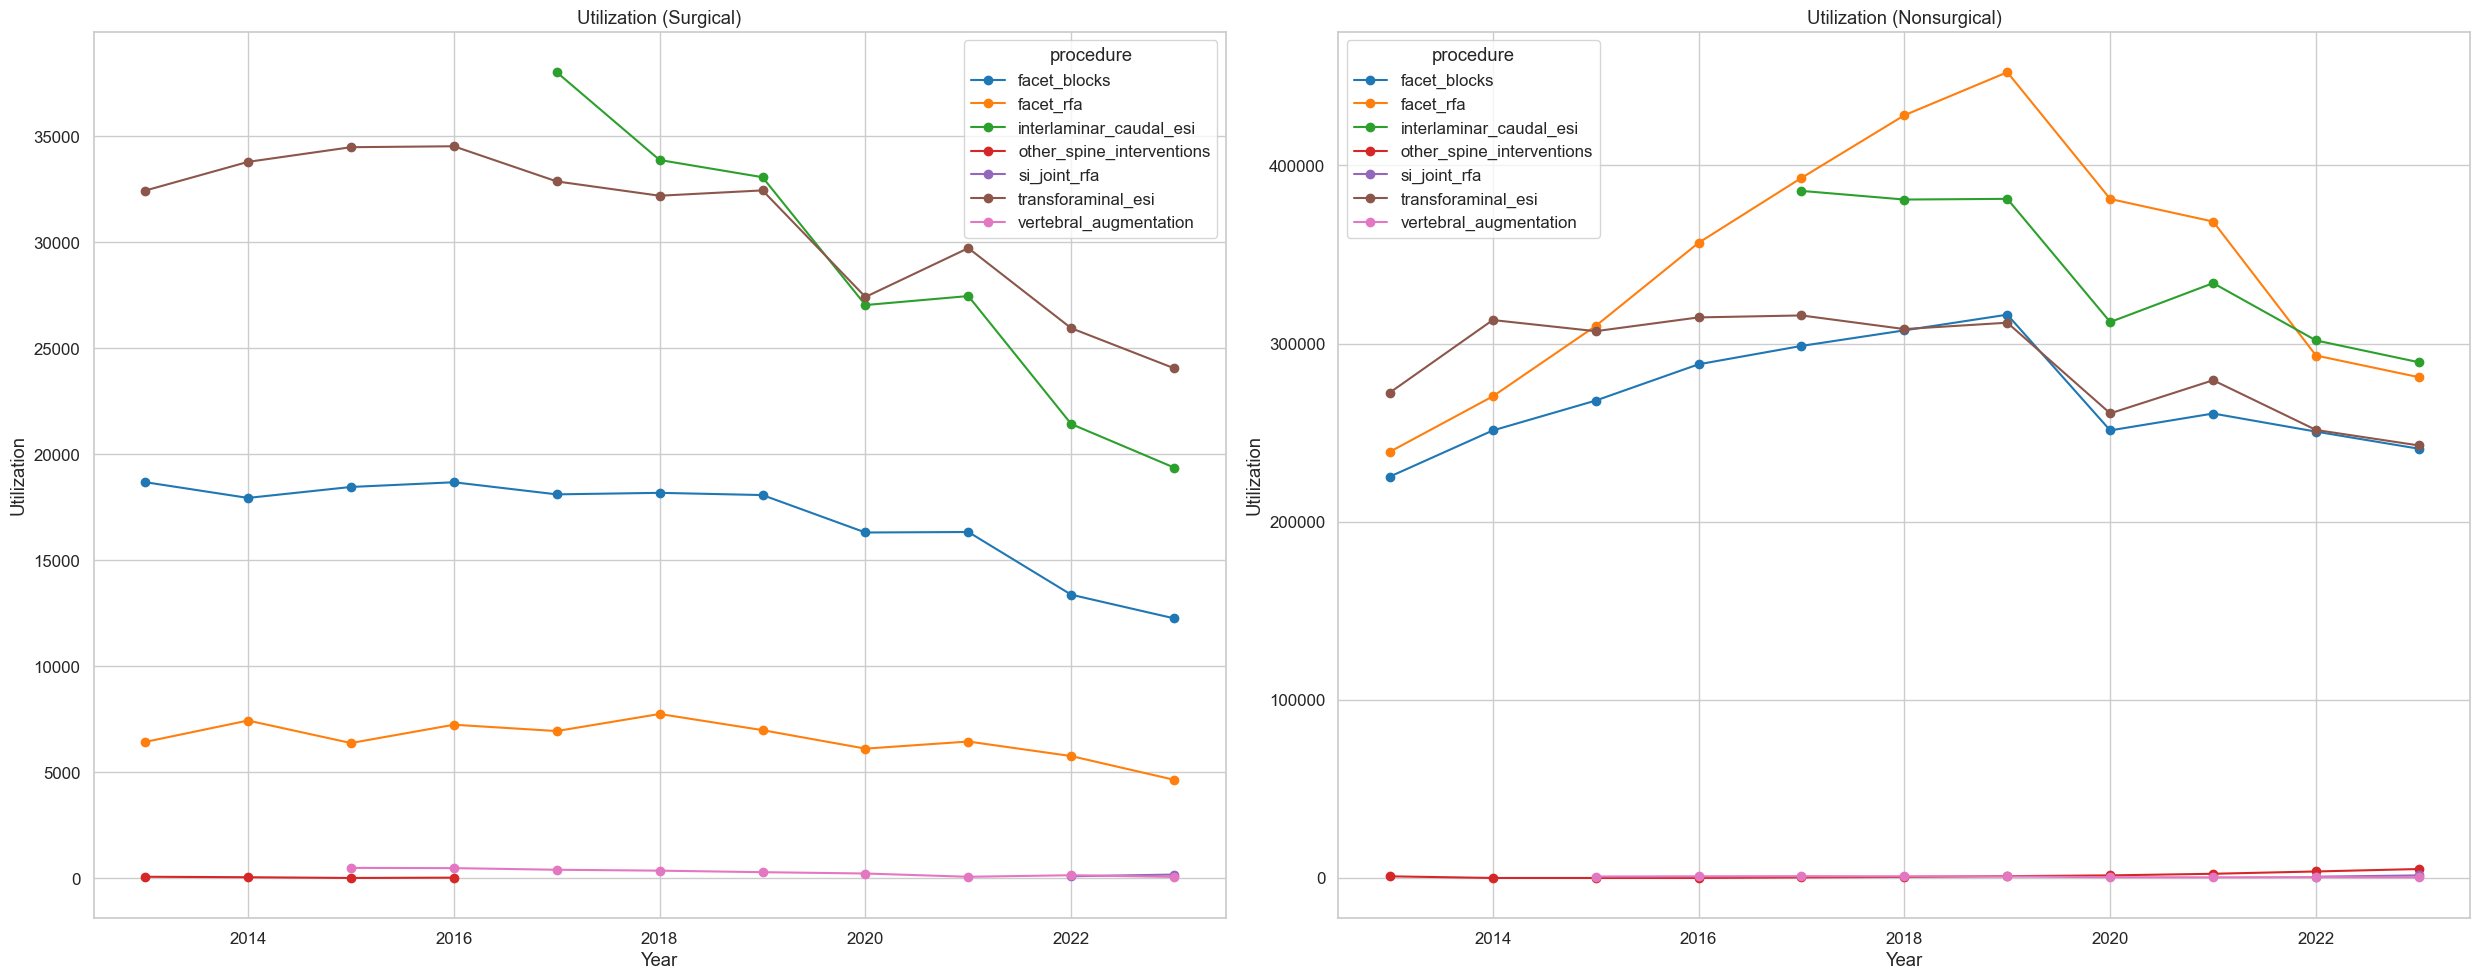

In [113]:
fig, axs = plt.subplots(1, 2, figsize=(25, 10)) 
for i, specialty in enumerate([util_2023_2013_adj_surg, util_2023_2013_adj_nonsurg]):
    grouped = specialty.groupby(groupby_key)
    p_num = 0
    
    for label, df in grouped:
        # Sort by year to ensure proper line plotting
        df_sorted = df.sort_values('year')

        x = df_sorted['year']
        y = df_sorted['Sum_Utilization']

        axs[i].plot(x, y, label=label, marker='o', markersize=6, linestyle='-', color=colors[p_num])
        p_num += 1
    
    axs[i].legend(title=groupby_key)
    axs[i].set_xlabel("Year")
    axs[i].set_ylabel("Utilization")
    axs[i].set_title(f"Utilization ({specialty_name[i]})")

plt.tight_layout()

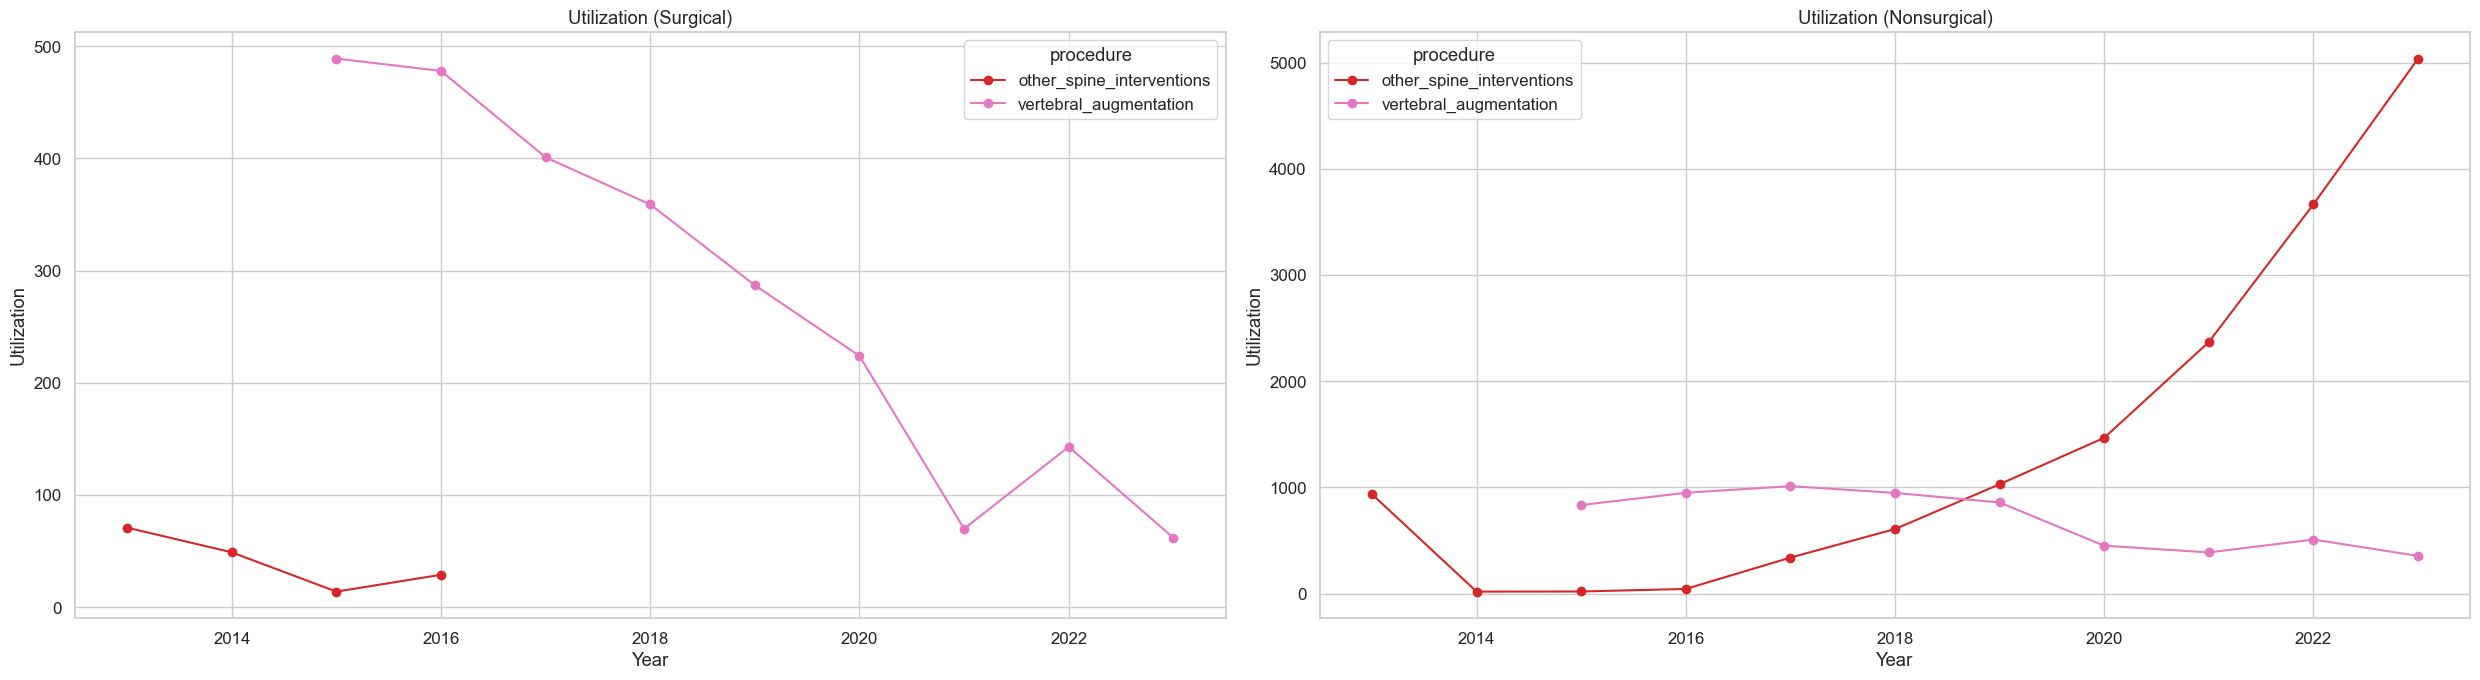

In [114]:
fig, axs = plt.subplots(1, 2, figsize=(25, 7)) 
for i, specialty in enumerate([util_2023_2013_adj_surg, util_2023_2013_adj_nonsurg]):
    grouped = specialty.groupby(groupby_key)
    p_num = 0
    
    for label, df in grouped:
        if label in ('vertebral_augmentation', 'other_spine_interventions'):
            # Sort by year to ensure proper line plotting
            df_sorted = df.sort_values('year')
    
            x = df_sorted['year']
            y = df_sorted['Sum_Utilization']
    
            axs[i].plot(x, y, label=label, marker='o', markersize=6, linestyle='-', color=colors[p_num])
        p_num += 1
    
    axs[i].legend(title=groupby_key)
    axs[i].set_xlabel("Year")
    axs[i].set_ylabel("Utilization")
    axs[i].set_title(f"Utilization ({specialty_name[i]})")

plt.tight_layout()

In [115]:
# fig, axs = plt.subplots(1, 2, figsize=(25, 10)) 
# for i, specialty in enumerate([util_2023_2013_adj_surg, util_2023_2013_adj_nonsurg]):
#     grouped = specialty.groupby(groupby_key)
#     p_num = 0
    
#     for label, df in grouped:
#         # Sort by year to ensure proper line plotting
#         df_sorted = df.sort_values('year')

#         x = df_sorted['year']
#         y = df_sorted['Sum_Utilization']

#         axs[i].plot(x, y, label=label, marker='o', markersize=6, linestyle='-', color=colors[p_num])
#         p_num += 1
    
#     axs[i].legend(title=groupby_key)
#     axs[i].set_xlabel("Year")
#     axs[i].set_ylabel("log(Utilization)")
#     axs[i].set_title(f"Utilization ({specialty_name[i]})")
#     axs[i].set_yscale("log")

# plt.tight_layout()

## Average Standardized Payment

In [116]:
util_2023_2013_adj_surg['CI_lower_avg_price_per_service'] = util_2023_2013_adj_surg['Avg_Price_per_service_adj'] - 1.96 * util_2023_2013_adj_surg['Avg_Price_per_service_adj_sem']
util_2023_2013_adj_surg['CI_upper_avg_price_per_service'] = util_2023_2013_adj_surg['Avg_Price_per_service_adj'] + 1.96 * util_2023_2013_adj_surg['Avg_Price_per_service_adj_sem']

util_2023_2013_adj_nonsurg['CI_lower_avg_price_per_service'] = util_2023_2013_adj_nonsurg['Avg_Price_per_service_adj'] - 1.96 * util_2023_2013_adj_nonsurg['Avg_Price_per_service_adj_sem']
util_2023_2013_adj_nonsurg['CI_upper_avg_price_per_service'] = util_2023_2013_adj_nonsurg['Avg_Price_per_service_adj'] + 1.96 * util_2023_2013_adj_nonsurg['Avg_Price_per_service_adj_sem']

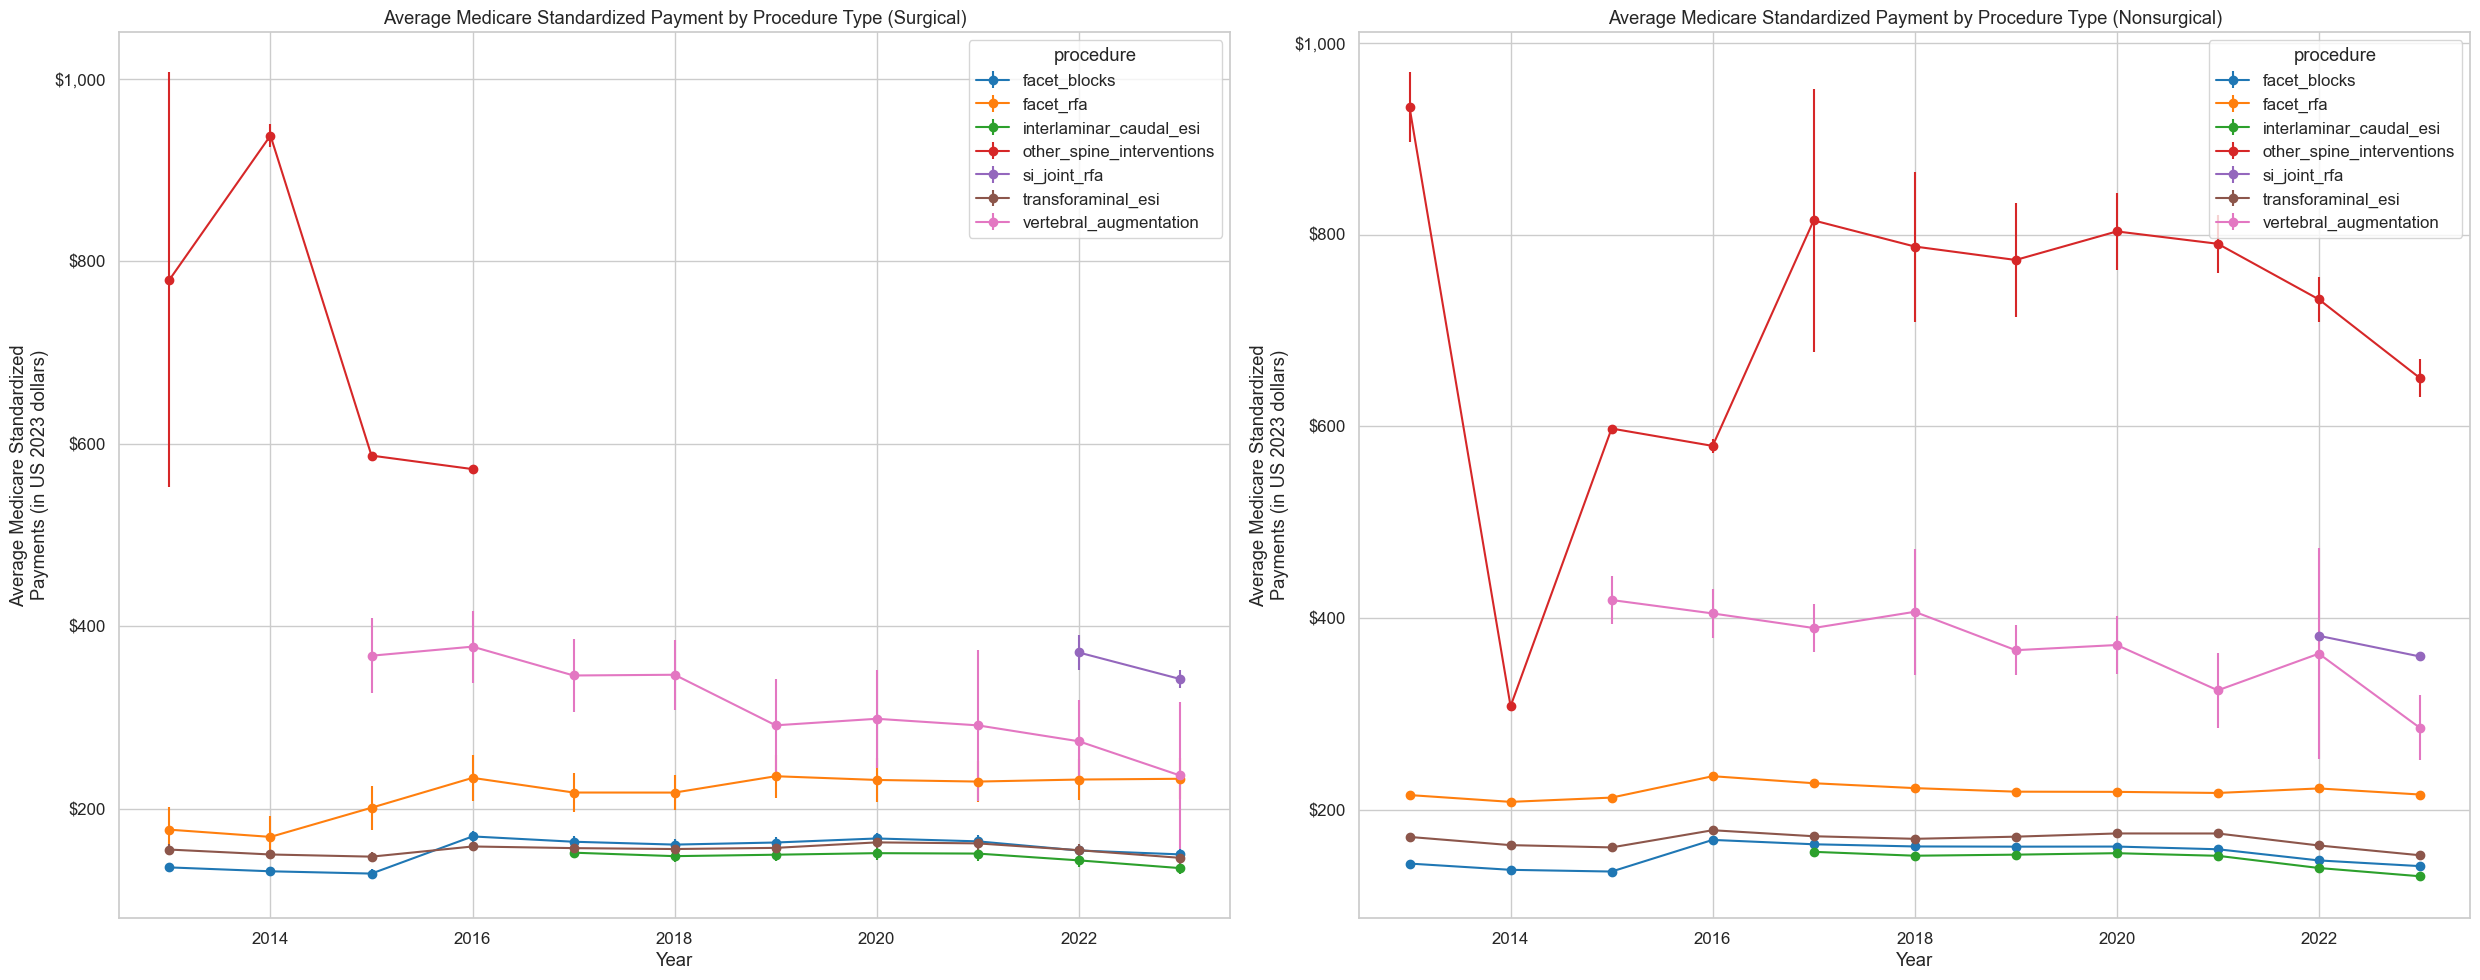

In [117]:
fig, axs = plt.subplots(1, 2, figsize=(25, 10)) 

for i, specialty in enumerate([util_2023_2013_adj_surg, util_2023_2013_adj_nonsurg]):
    grouped = specialty.groupby(groupby_key)
    p_num = 0
    
    for label, df in grouped:
        # Sort by year to ensure proper line plotting
        df_sorted = df.sort_values('year')
        
        x = df_sorted['year']
        y = df_sorted['Avg_Price_per_service_adj']
    
        # Compute error bars from CI bounds
        yerr = [y - df_sorted['CI_lower_avg_price_per_service'], df_sorted['CI_upper_avg_price_per_service'] - y]
    
        axs[i].errorbar(x, y, yerr=yerr, label=label, marker='o', markersize=6, linestyle='-', color=colors[p_num])
        p_num += 1
    
    axs[i].legend(title=groupby_key)
    axs[i].set_xlabel("Year")
    axs[i].set_ylabel("Average Medicare Standardized\nPayments (in US 2023 dollars)")
    axs[i].set_title(f"Average Medicare Standardized Payment by Procedure Type ({specialty_name[i]})")
    
    axs[i].yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"${x:,.0f}"))

plt.tight_layout()

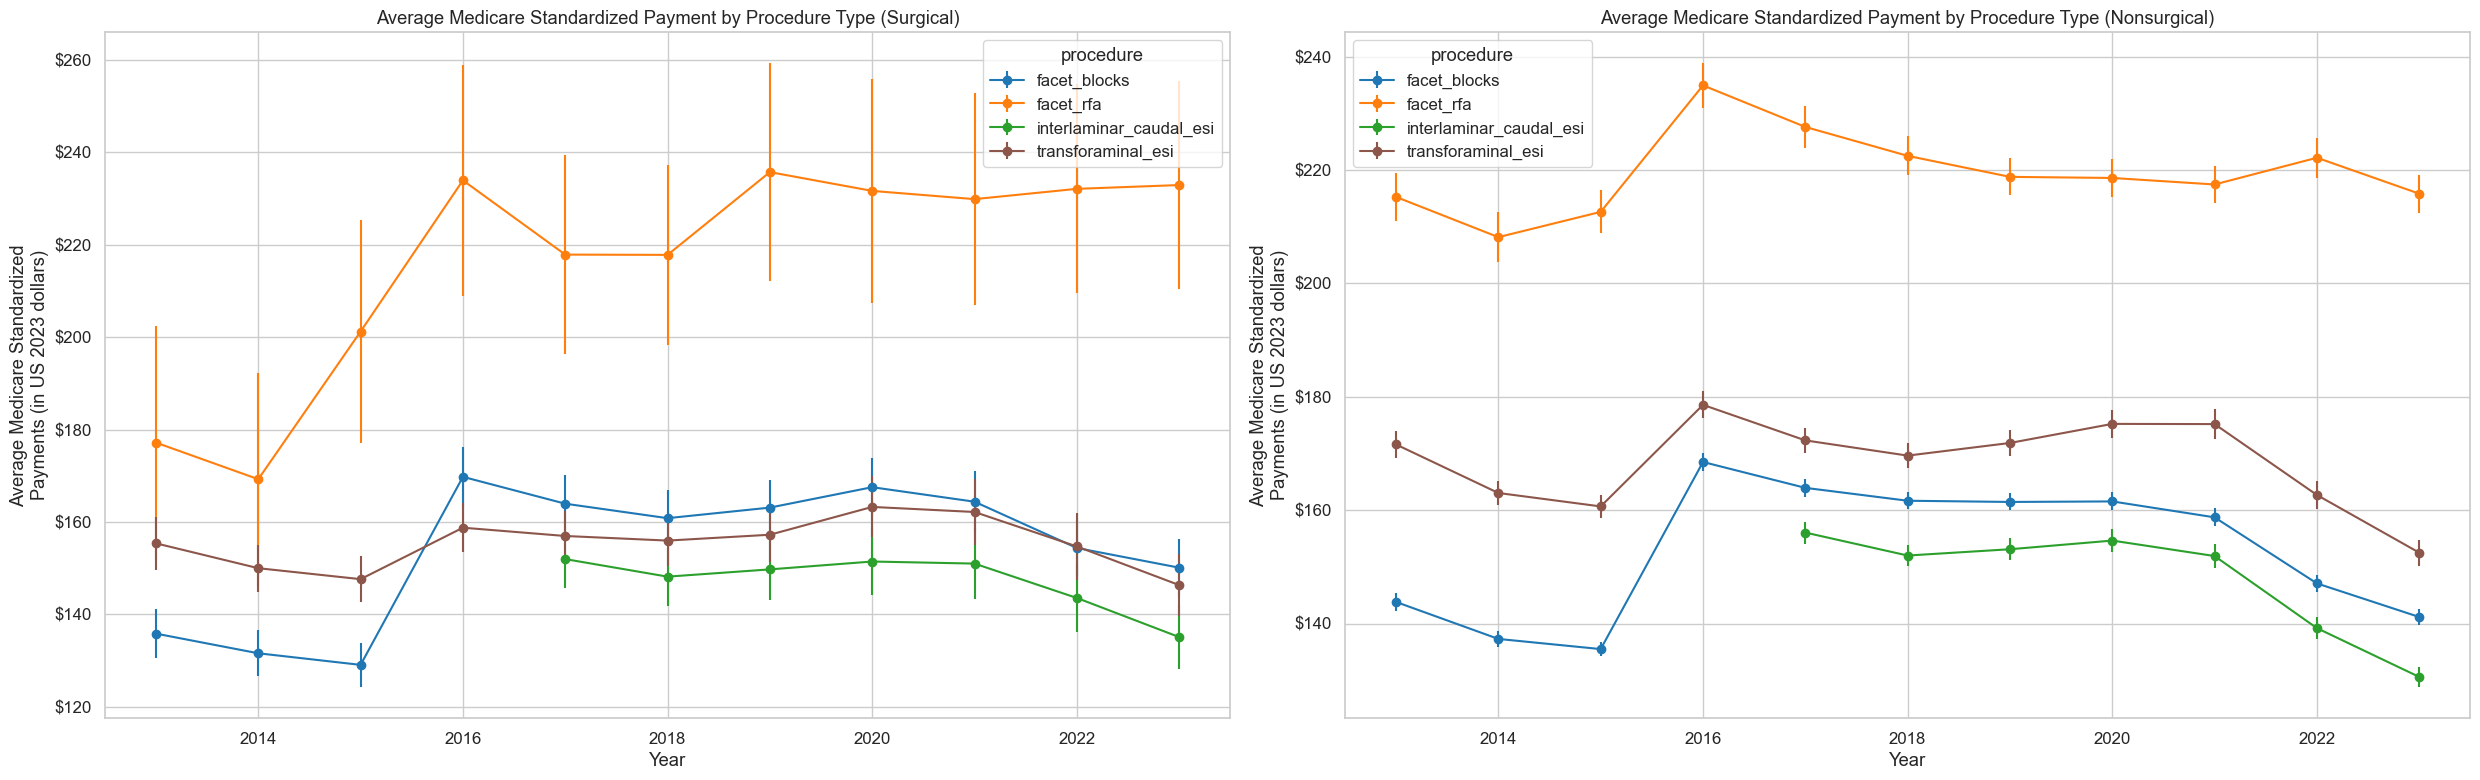

In [118]:
fig, axs = plt.subplots(1, 2, figsize=(25, 8)) 
for i, specialty in enumerate([util_2023_2013_adj_surg, util_2023_2013_adj_nonsurg]):
    grouped = specialty.groupby(groupby_key)
    p_num = 0
    
    for label, df in grouped:
        if label in ('facet_rfa', 'transforaminal_esi', 'facet_blocks', 'interlaminar_caudal_esi'):
            # Sort by year to ensure proper line plotting
            df_sorted = df.sort_values('year')
            
            x = df_sorted['year']
            y = df_sorted['Avg_Price_per_service_adj']
        
            # Compute error bars from CI bounds
            yerr = [y - df_sorted['CI_lower_avg_price_per_service'], df_sorted['CI_upper_avg_price_per_service'] - y]
    
            axs[i].errorbar(x, y, yerr=yerr, label=label, marker='o', markersize=6, linestyle='-', color=colors[p_num])
        p_num += 1
    
    axs[i].legend(title=groupby_key)
    axs[i].set_xlabel("Year")
    axs[i].set_ylabel("Average Medicare Standardized\nPayments (in US 2023 dollars)")
    axs[i].set_title(f"Average Medicare Standardized Payment by Procedure Type ({specialty_name[i]})")

    axs[i].yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"${x:,.0f}"))

plt.tight_layout()

## Average Standardized Payment Growth Rate

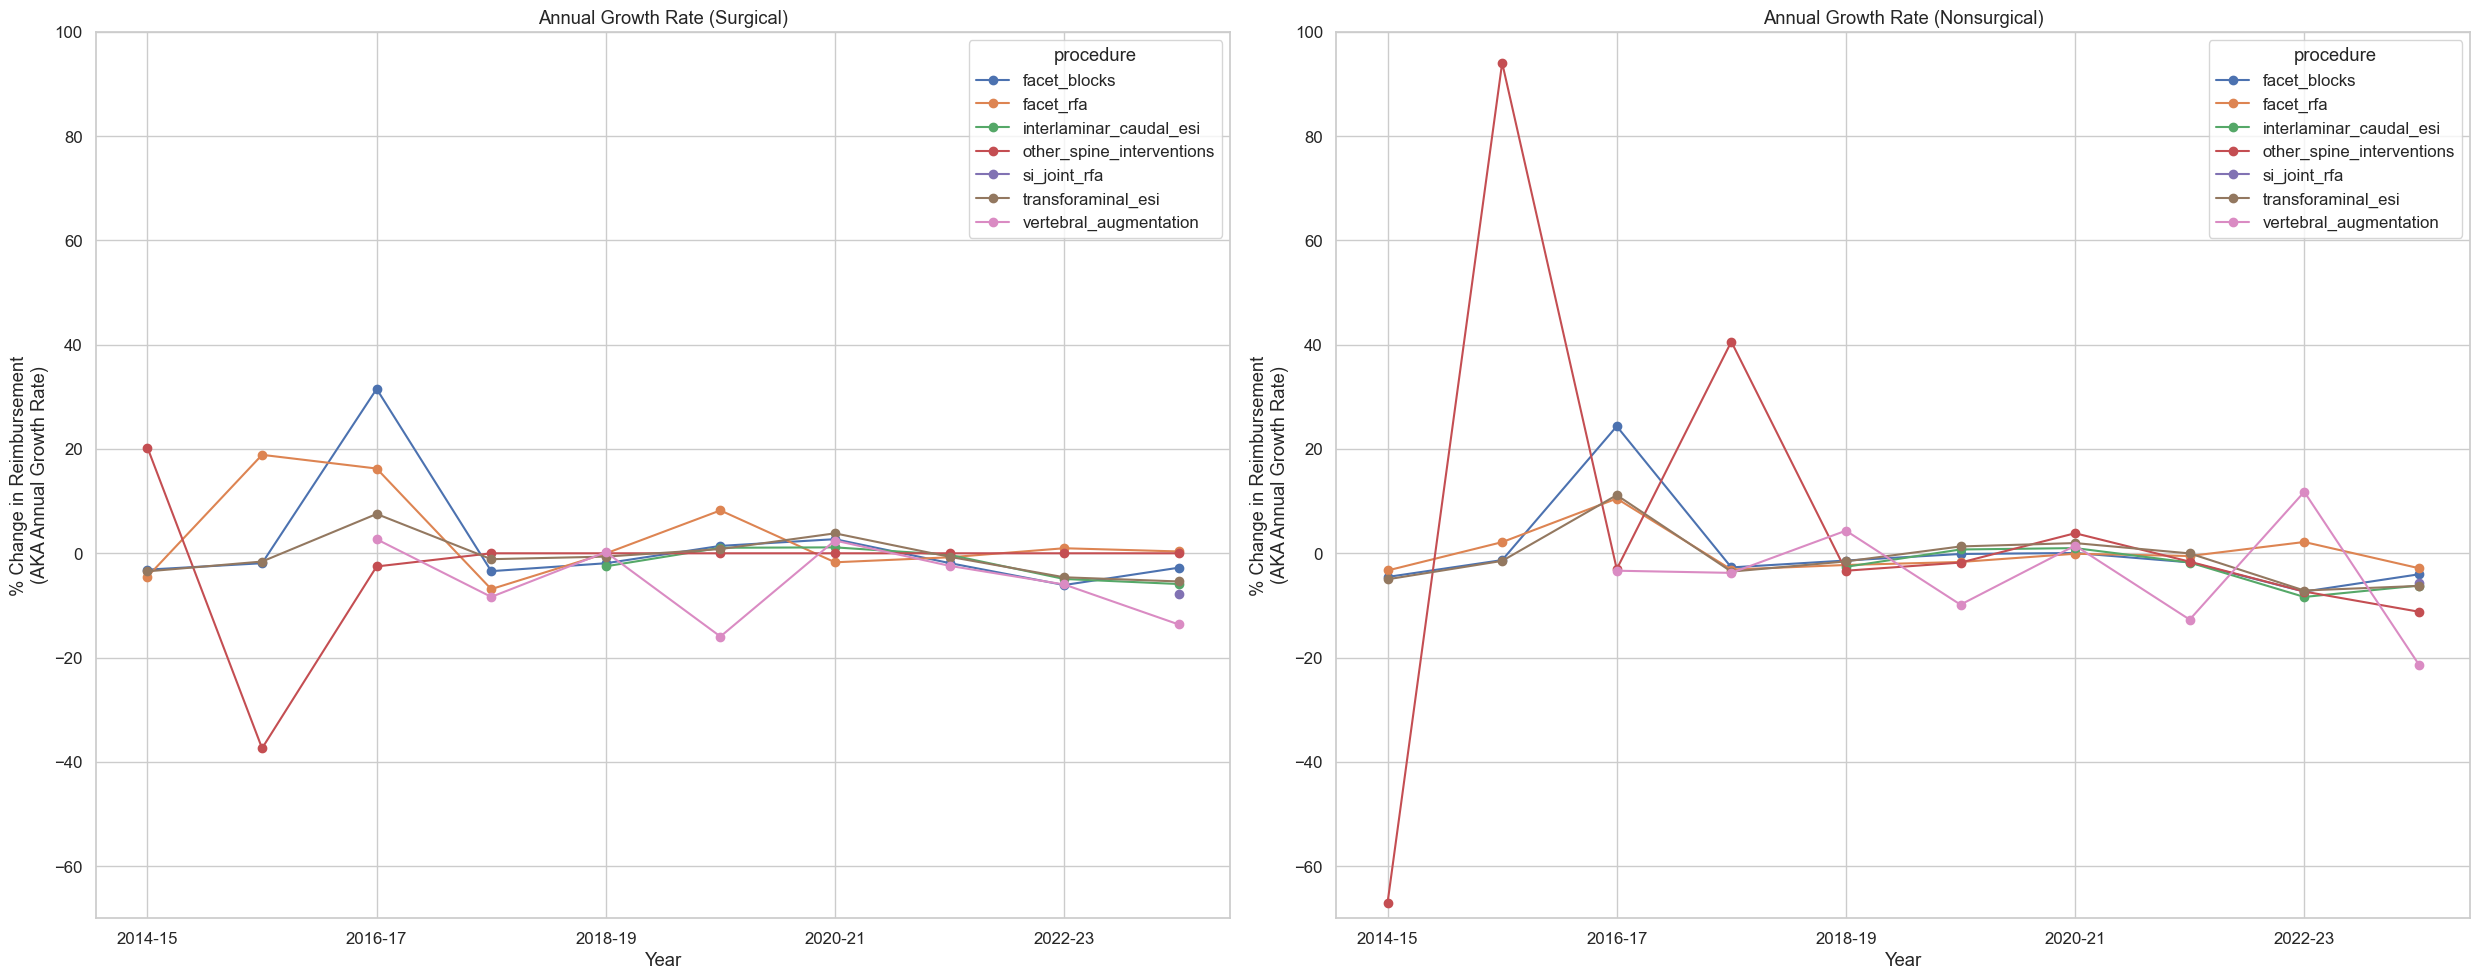

In [176]:
fig, axs = plt.subplots(1, 2, figsize=(25, 10)) 

aagr = {'Surgical': [], 'Nonsurgical': []}
aagr_no_interp = {'Surgical': [], 'Nonsurgical': []}
all_deltas = {'Surgical': [], 'Nonsurgical': []}

for i, specialty in enumerate([util_2023_2013_adj_surg, util_2023_2013_adj_nonsurg]):
    grouped = specialty.groupby(groupby_key)
    for label, df in grouped:
        # Sort by year to ensure proper line plotting
        df_sorted = df.sort_values('year')
        
        x = df_sorted['year'].tolist()
        y = df_sorted['Avg_Price_per_service_adj'].tolist()
    
        pairs = {x[i]: item for i, item in enumerate(y)}
    
        x_new = list(range(2013, 2024))
    
        y_new = [pairs[year] if year in pairs else np.nan for year in x_new]
        delta = pd.Series(y_new).interpolate().pct_change().to_numpy() * 100

        axs[i].plot(range(len(delta)), delta, label=label, marker='o', markersize=6, linestyle='-')

        # Use this to compute AAGR per procedure later
        aagr[specialty_name[i]].append([label, np.nanmean(delta), specialty_name[i]])

        # Compute a version of AAGR without interpolation
        delta_no_interp = pd.Series(y_new).pct_change().to_numpy() * 100
        aagr_no_interp[specialty_name[i]].append([label, np.nanmean(delta_no_interp)])

        # Use this to plot average growth rate across procedures later
        all_deltas[specialty_name[i]].append(delta)

    axs[i].legend(title=groupby_key)
    axs[i].set_xlabel("Year")
    axs[i].set_xticks([1, 3, 5, 7, 9])
    axs[i].set_xticklabels(['2014-15', '2016-17', '2018-19', '2020-21', '2022-23']),
    axs[i].set_ylabel("% Change in Reimbursement\n(AKA Annual Growth Rate)")
    axs[i].set_ylim([-70, 100])
    axs[i].set_title(f"Annual Growth Rate ({specialty_name[i]})")

plt.tight_layout()

In [152]:
pd.DataFrame(
    aagr['Surgical'] + aagr['Nonsurgical'], columns=['procedure', 'AAGR (%)', 'specialty']
).sort_values(by=['AAGR (%)']).to_csv("results/pain_aagr_by_procedure.csv", index=False)

In [158]:
aagr = {'Surgical': [], 'Nonsurgical': []}
aagr_no_interp = {'Surgical': [], 'Nonsurgical': []}
all_deltas = {'Surgical': [], 'Nonsurgical': []}

for i, specialty in enumerate([util_2023_2013_adj_surg_by_cpt, util_2023_2013_adj_nonsurg_by_cpt]):
    grouped = specialty.groupby('HCPCS_Cd')
    for label, df in grouped:
        # Sort by year to ensure proper line plotting
        df_sorted = df.sort_values('year')
        
        x = df_sorted['year'].tolist()
        y = df_sorted['Avg_Price_per_service_adj'].tolist()
    
        pairs = {x[i]: item for i, item in enumerate(y)}
    
        x_new = list(range(2013, 2024))
    
        y_new = [pairs[year] if year in pairs else np.nan for year in x_new]
        delta = pd.Series(y_new).interpolate().pct_change().to_numpy() * 100

        axs[i].plot(range(len(delta)), delta, label=label, marker='o', markersize=6, linestyle='-')

        # Use this to compute AAGR per procedure later
        aagr[specialty_name[i]].append([label, np.nanmean(delta), specialty_name[i]])

        # Compute a version of AAGR without interpolation
        delta_no_interp = pd.Series(y_new).pct_change().to_numpy() * 100
        aagr_no_interp[specialty_name[i]].append([label, np.nanmean(delta_no_interp)])

        # Use this to plot average growth rate across procedures later
        all_deltas[specialty_name[i]].append(delta)

In [159]:
pd.DataFrame(
    aagr['Surgical'] + aagr['Nonsurgical'], columns=['cpt', 'AAGR (%)', 'specialty']
).sort_values(by=['AAGR (%)']).to_csv("results/pain_aagr_by_cpt_code.csv", index=False)

/var/folders/jv/hvl4bxhn45d10f4fq__lhlxm0000gn/T/ipykernel_57424/798989267.py:5: RuntimeWarning: Mean of empty slice
  aagr = np.nanmean(np.array(specialty), axis=0)


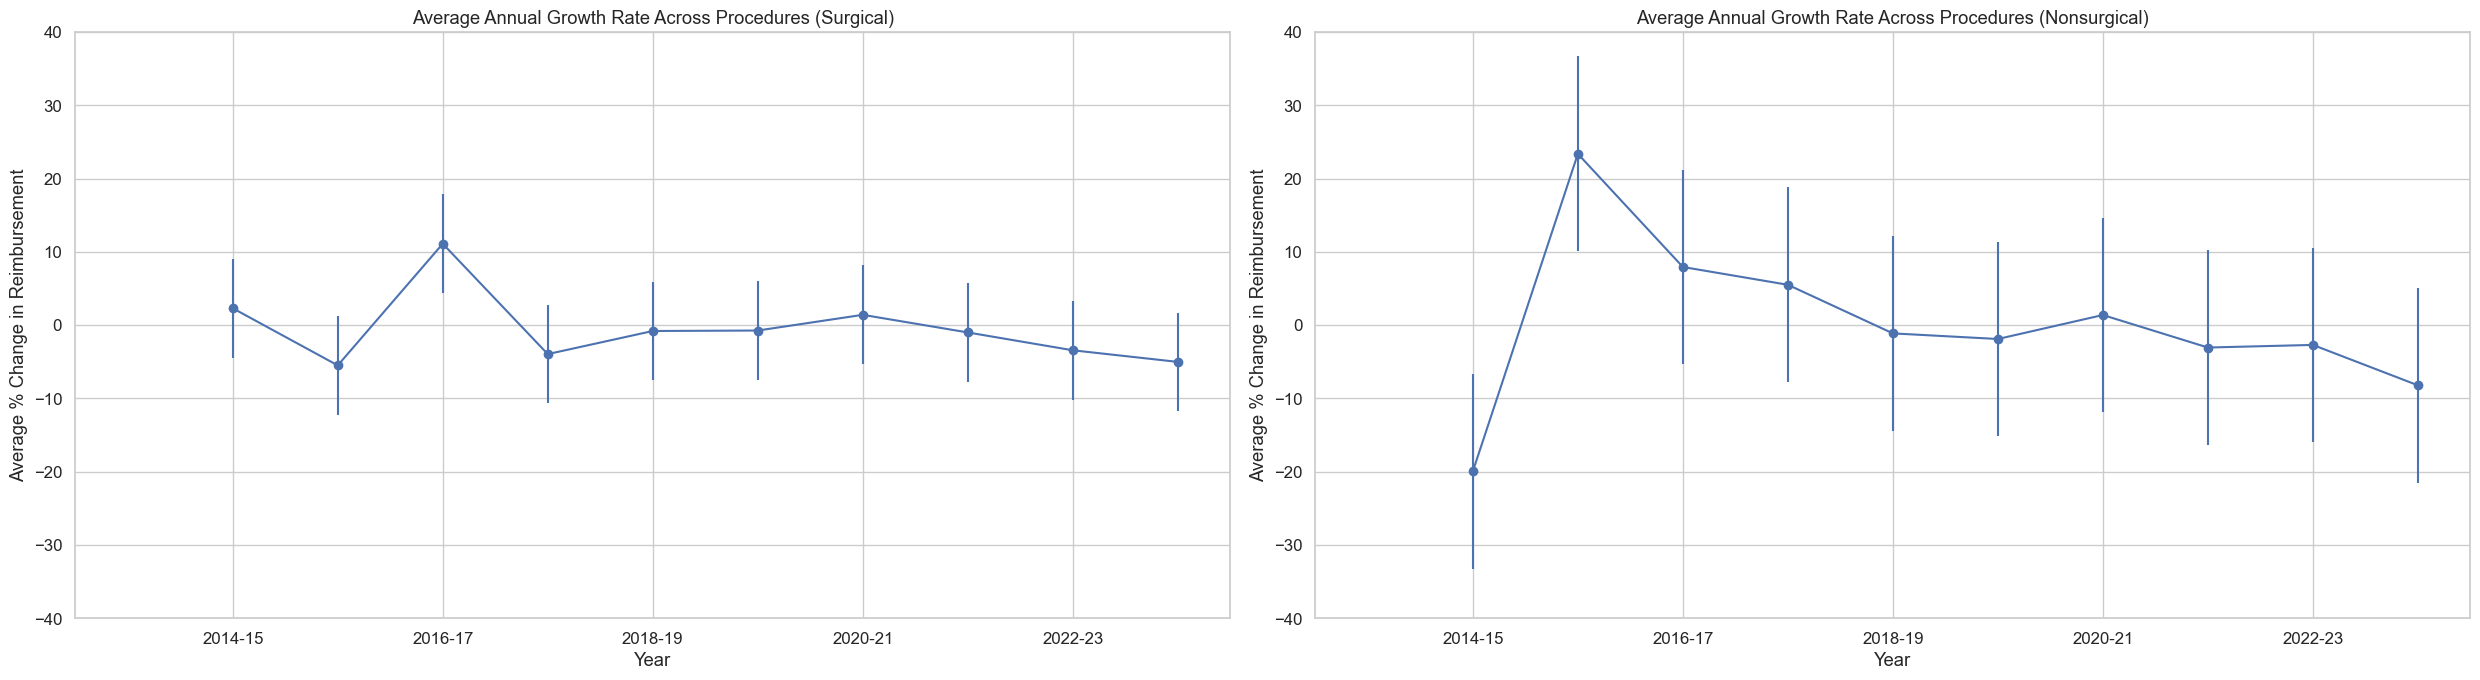

In [177]:
fig, axs = plt.subplots(1, 2, figsize=(25, 7)) 

i = 0
for key, specialty in all_deltas.items():
    aagr = np.nanmean(np.array(specialty), axis=0)
    sem = np.nanstd(np.array(specialty), ddof=1) / np.sqrt(len(specialty))
    
    ci_lower = aagr - 1.96 * sem
    ci_upper = aagr + 1.96 * sem
    
    # Compute error bars from CI bounds
    yerr = [aagr - ci_lower, ci_upper - aagr]

    axs[i].errorbar(range(len(aagr)), aagr, yerr=yerr,  marker='o', markersize=6, linestyle='-')

    axs[i].set_xlabel("Year")
    axs[i].set_xticks([1, 3, 5, 7, 9])
    axs[i].set_xticklabels(['2014-15', '2016-17', '2018-19', '2020-21', '2022-23']),
    axs[i].set_ylabel("Average % Change in Reimbursement")
    axs[i].set_ylim([-40, 40])
    axs[i].set_title(f"Average Annual Growth Rate Across Procedures ({specialty_name[i]})")

    i += 1

plt.tight_layout()

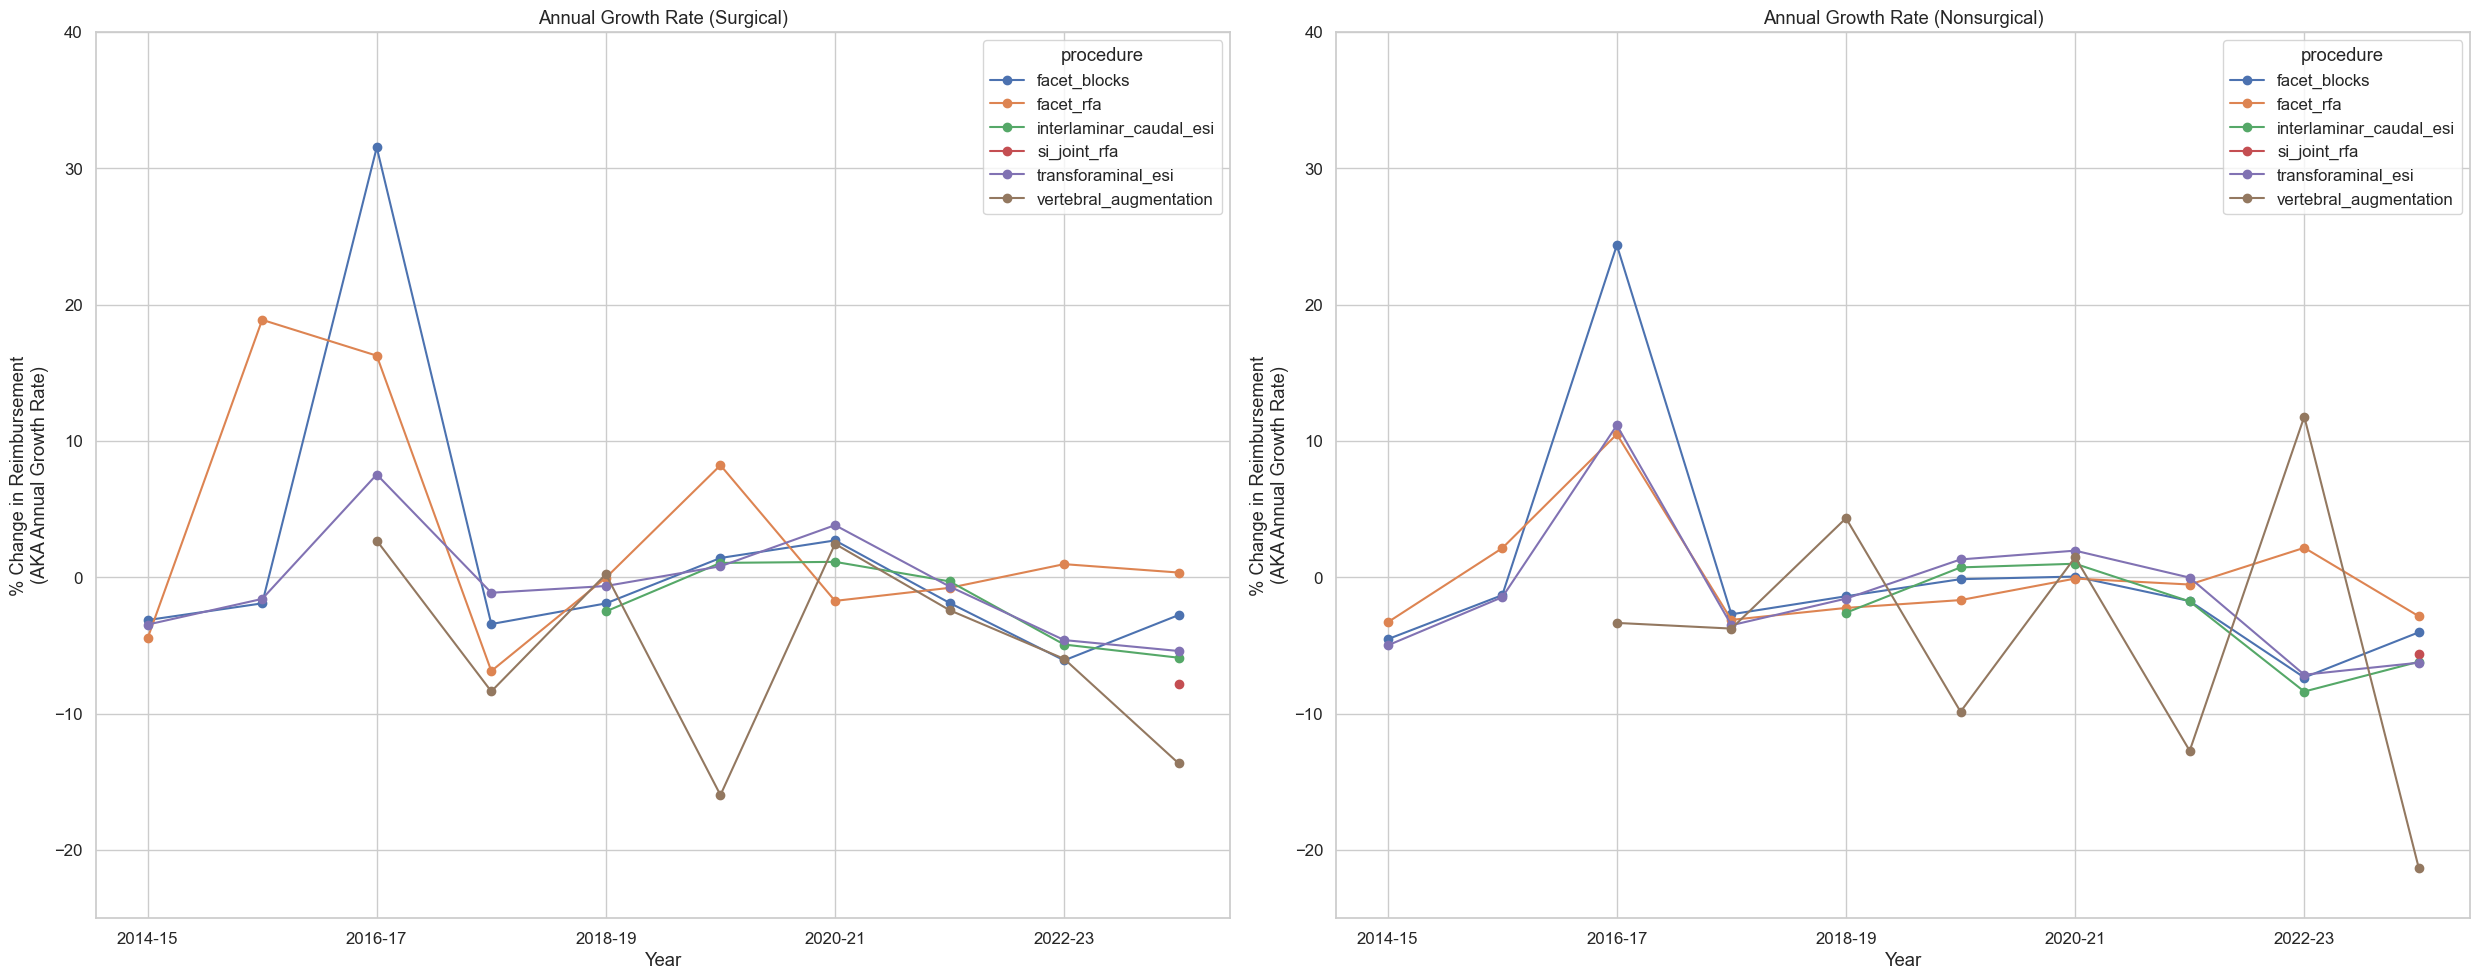

In [156]:
fig, axs = plt.subplots(1, 2, figsize=(25, 10)) 

aagr = {'Surgical': [], 'Nonsurgical': []}
aagr_no_interp = {'Surgical': [], 'Nonsurgical': []}
all_deltas = {'Surgical': [], 'Nonsurgical': []}

for i, specialty in enumerate([util_2023_2013_adj_surg, util_2023_2013_adj_nonsurg]):
    grouped = specialty.groupby(groupby_key)
    for label, df in grouped:
        if label == ('other_spine_interventions'):
            continue 
        # Sort by year to ensure proper line plotting
        df_sorted = df.sort_values('year')
        
        x = df_sorted['year'].tolist()
        y = df_sorted['Avg_Price_per_service_adj'].tolist()
    
        pairs = {x[i]: item for i, item in enumerate(y)}
    
        x_new = list(range(2013, 2024))
    
        y_new = [pairs[year] if year in pairs else np.nan for year in x_new]
        delta = pd.Series(y_new).interpolate().pct_change().to_numpy() * 100

        axs[i].plot(range(len(delta)), delta, label=label, marker='o', markersize=6, linestyle='-')

        # Use this to compute AAGR per procedure later
        aagr[specialty_name[i]].append([label, np.nanmean(delta), specialty_name[i]])

        # Compute a version of AAGR without interpolation
        delta_no_interp = pd.Series(y_new).pct_change().to_numpy() * 100
        aagr_no_interp[specialty_name[i]].append([label, np.nanmean(delta_no_interp)])

        # Use this to plot average growth rate across procedures later
        all_deltas[specialty_name[i]].append(delta)

    axs[i].legend(title=groupby_key)
    axs[i].set_xlabel("Year")
    axs[i].set_xticks([1, 3, 5, 7, 9])
    axs[i].set_xticklabels(['2014-15', '2016-17', '2018-19', '2020-21', '2022-23']),
    axs[i].set_ylabel("% Change in Reimbursement\n(AKA Annual Growth Rate)")
    axs[i].set_ylim([-25, 40])
    axs[i].set_title(f"Annual Growth Rate ({specialty_name[i]})")

plt.tight_layout()

/var/folders/jv/hvl4bxhn45d10f4fq__lhlxm0000gn/T/ipykernel_57424/798989267.py:5: RuntimeWarning: Mean of empty slice
  aagr = np.nanmean(np.array(specialty), axis=0)


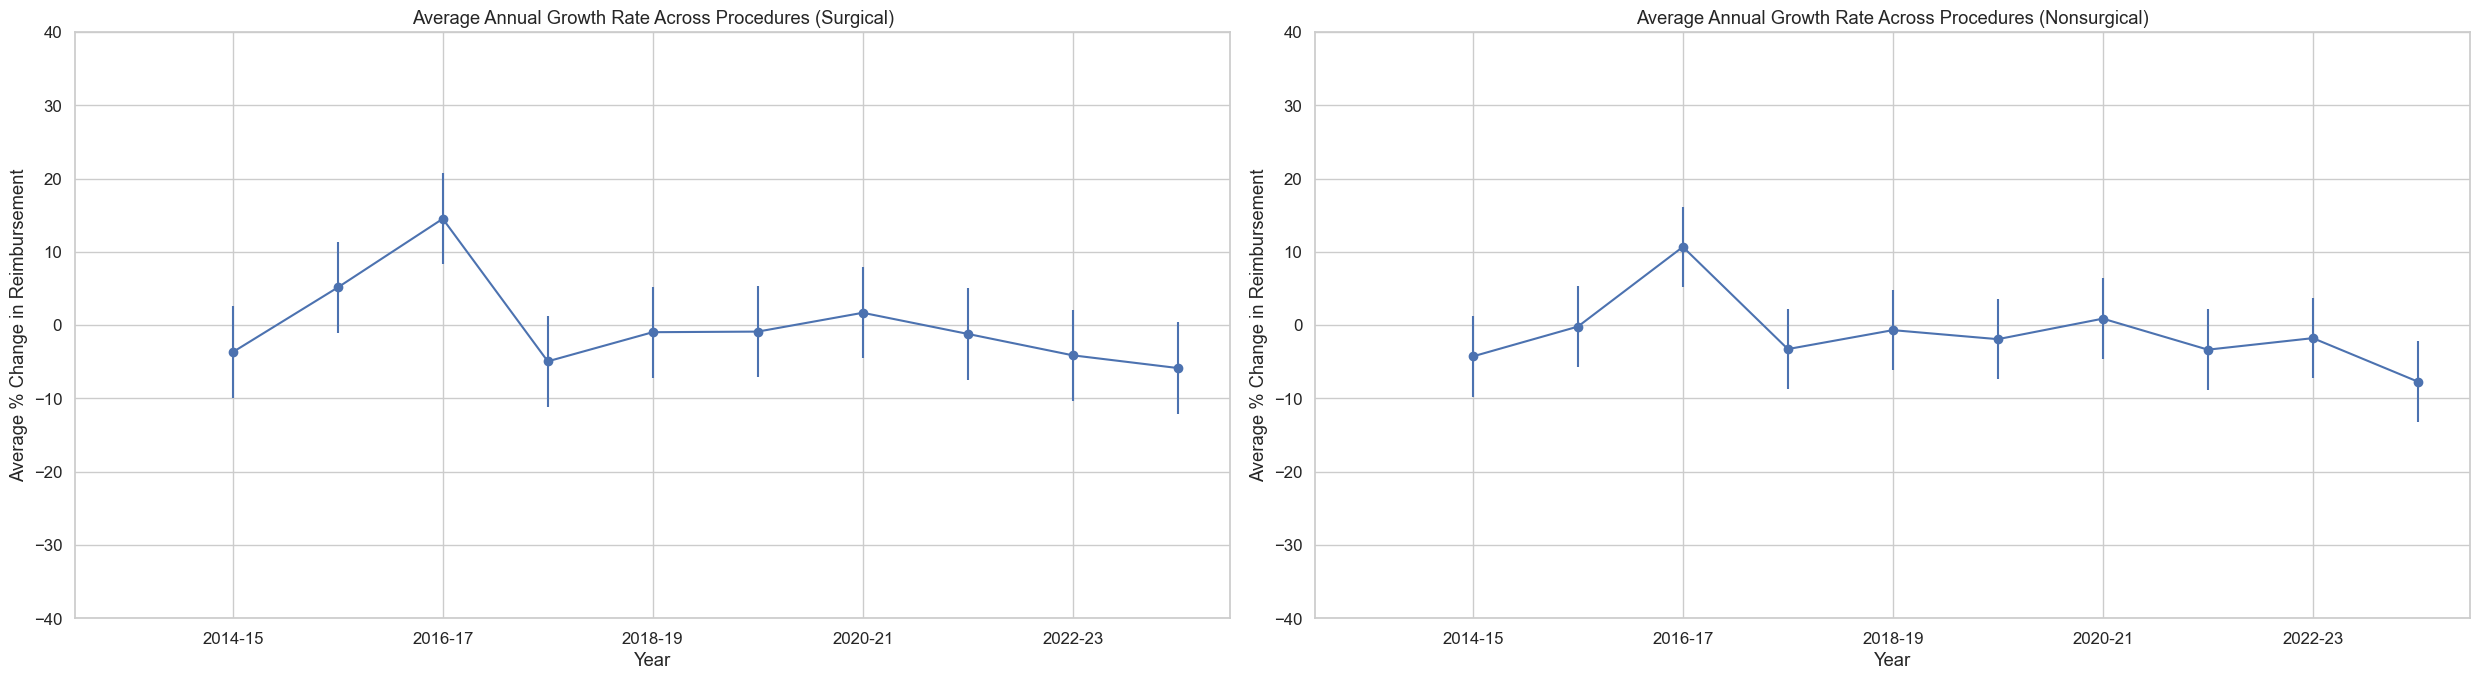

In [157]:
fig, axs = plt.subplots(1, 2, figsize=(25, 7)) 

i = 0
for key, specialty in all_deltas.items():
    aagr = np.nanmean(np.array(specialty), axis=0)
    sem = np.nanstd(np.array(specialty), ddof=1) / np.sqrt(len(specialty))
    
    ci_lower = aagr - 1.96 * sem
    ci_upper = aagr + 1.96 * sem
    
    # Compute error bars from CI bounds
    yerr = [aagr - ci_lower, ci_upper - aagr]

    axs[i].errorbar(range(len(aagr)), aagr, yerr=yerr,  marker='o', markersize=6, linestyle='-')

    axs[i].set_xlabel("Year")
    axs[i].set_xticks([1, 3, 5, 7, 9])
    axs[i].set_xticklabels(['2014-15', '2016-17', '2018-19', '2020-21', '2022-23']),
    axs[i].set_ylabel("Average % Change in Reimbursement")
    axs[i].set_ylim([-40, 40])
    axs[i].set_title(f"Average Annual Growth Rate Across Procedures ({specialty_name[i]})")

    i += 1

plt.tight_layout()

## Total Payment

In [162]:
util_2023_2013_adj_surg['CI_lower_tot_pymt'] = util_2023_2013_adj_surg['Tot_Pymt_adj'] - 1.96 * util_2023_2013_adj_surg['Tot_Pymt_adj_sem']
util_2023_2013_adj_surg['CI_upper_tot_pymt'] = util_2023_2013_adj_surg['Tot_Pymt_adj'] + 1.96 * util_2023_2013_adj_surg['Tot_Pymt_adj_sem']

util_2023_2013_adj_nonsurg['CI_lower_tot_pymt'] = util_2023_2013_adj_nonsurg['Tot_Pymt_adj'] - 1.96 * util_2023_2013_adj_nonsurg['Tot_Pymt_adj_sem']
util_2023_2013_adj_nonsurg['CI_upper_tot_pymt'] = util_2023_2013_adj_nonsurg['Tot_Pymt_adj'] + 1.96 * util_2023_2013_adj_nonsurg['Tot_Pymt_adj_sem']

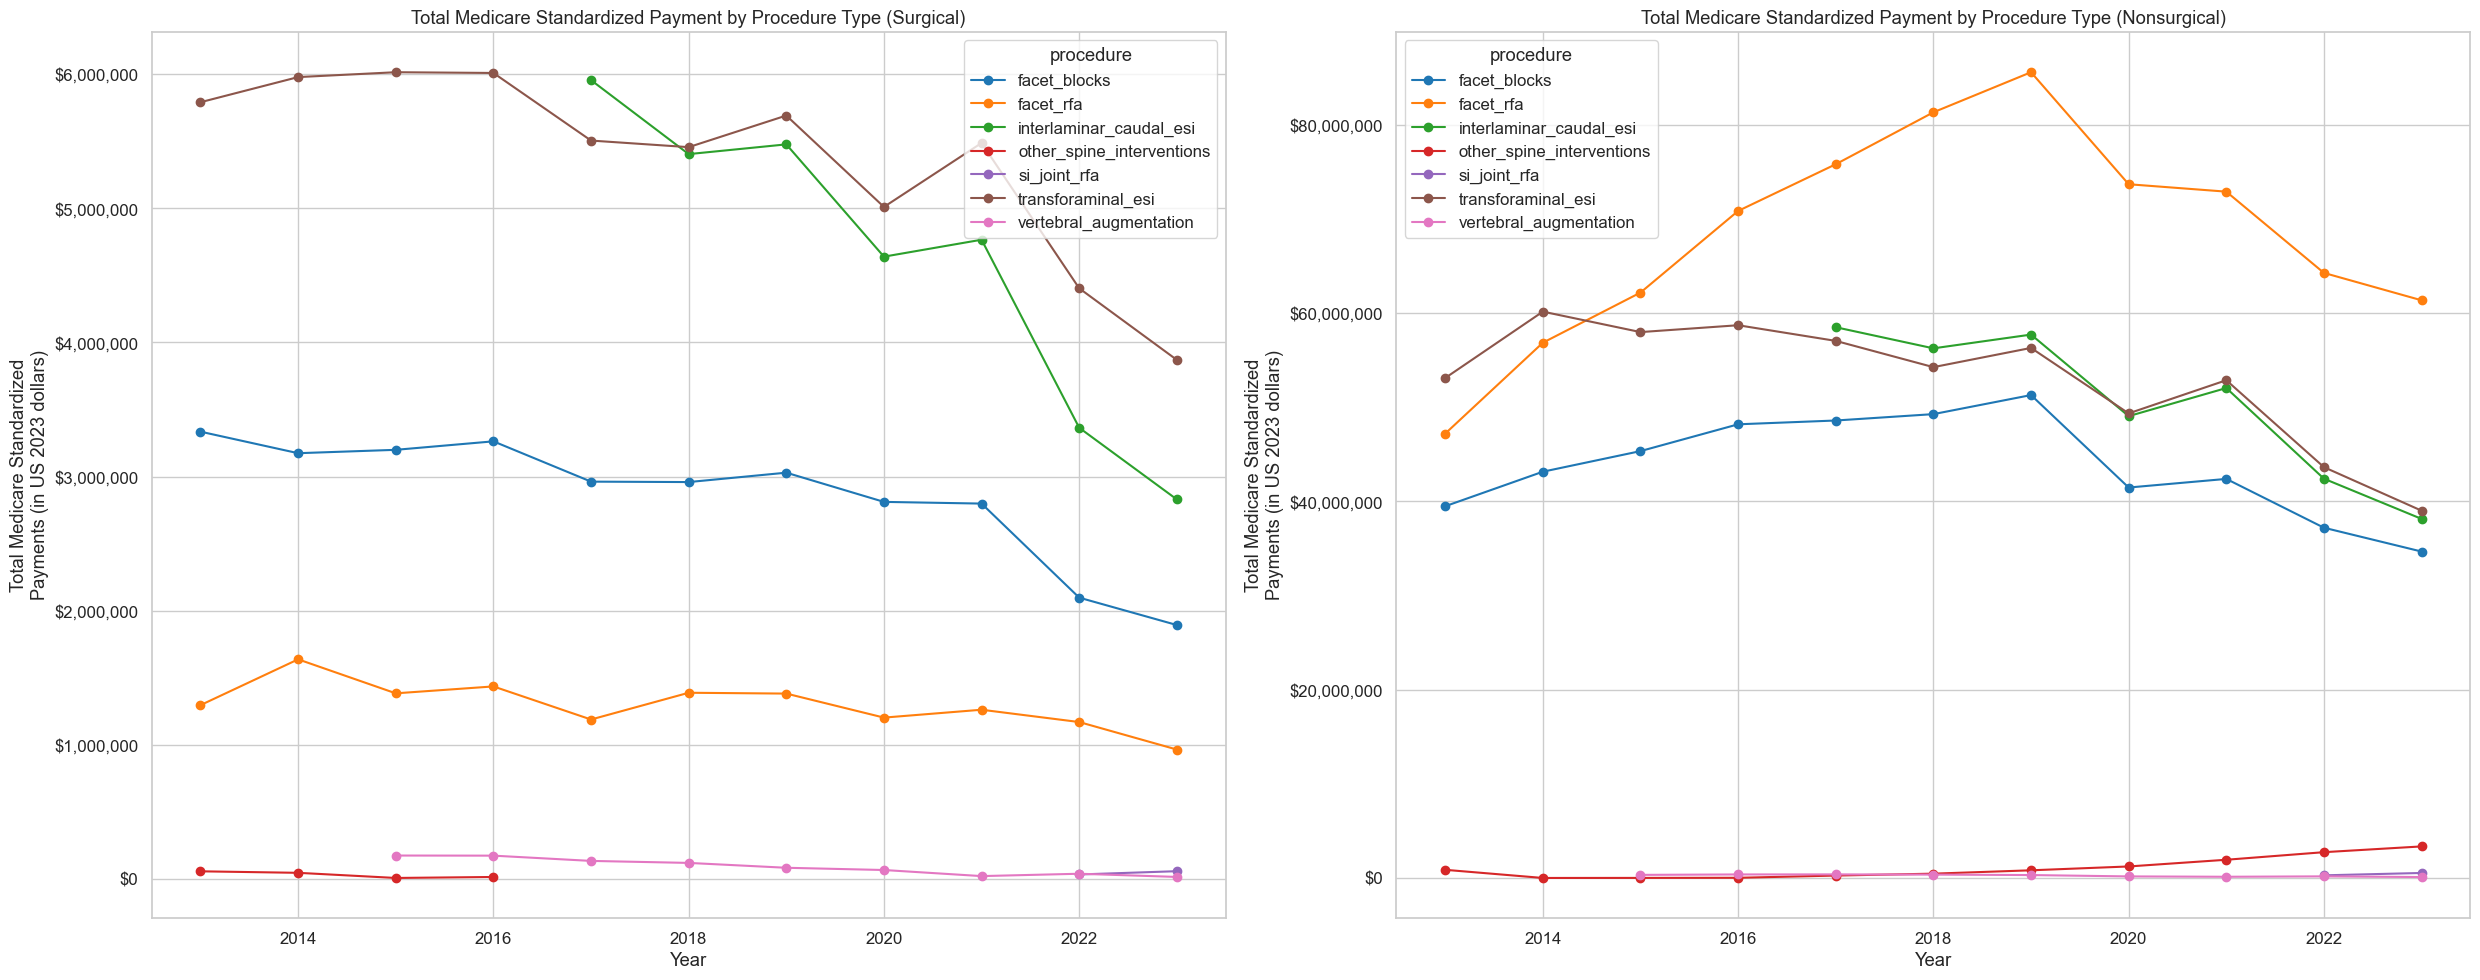

In [163]:
fig, axs = plt.subplots(1, 2, figsize=(25, 10)) 

for i, specialty in enumerate([util_2023_2013_adj_surg, util_2023_2013_adj_nonsurg]):
    grouped = specialty.groupby(groupby_key)
    p_num = 0

    for label, df in grouped:
        # Sort by year to ensure proper line plotting
        df_sorted = df.sort_values('year')
        
        x = df_sorted['year']
        y = df_sorted['Sum_Pymt_adj']
    
        axs[i].plot(x, y, label=label, marker='o', markersize=6, linestyle='-', color=colors[p_num])
        p_num += 1
    
    axs[i].legend(title=groupby_key)
    axs[i].set_xlabel("Year")
    axs[i].set_ylabel("Total Medicare Standardized\nPayments (in US 2023 dollars)")
    axs[i].set_title(f"Total Medicare Standardized Payment by Procedure Type ({specialty_name[i]})")
    
    axs[i].yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"${x:,.0f}"))

plt.tight_layout()

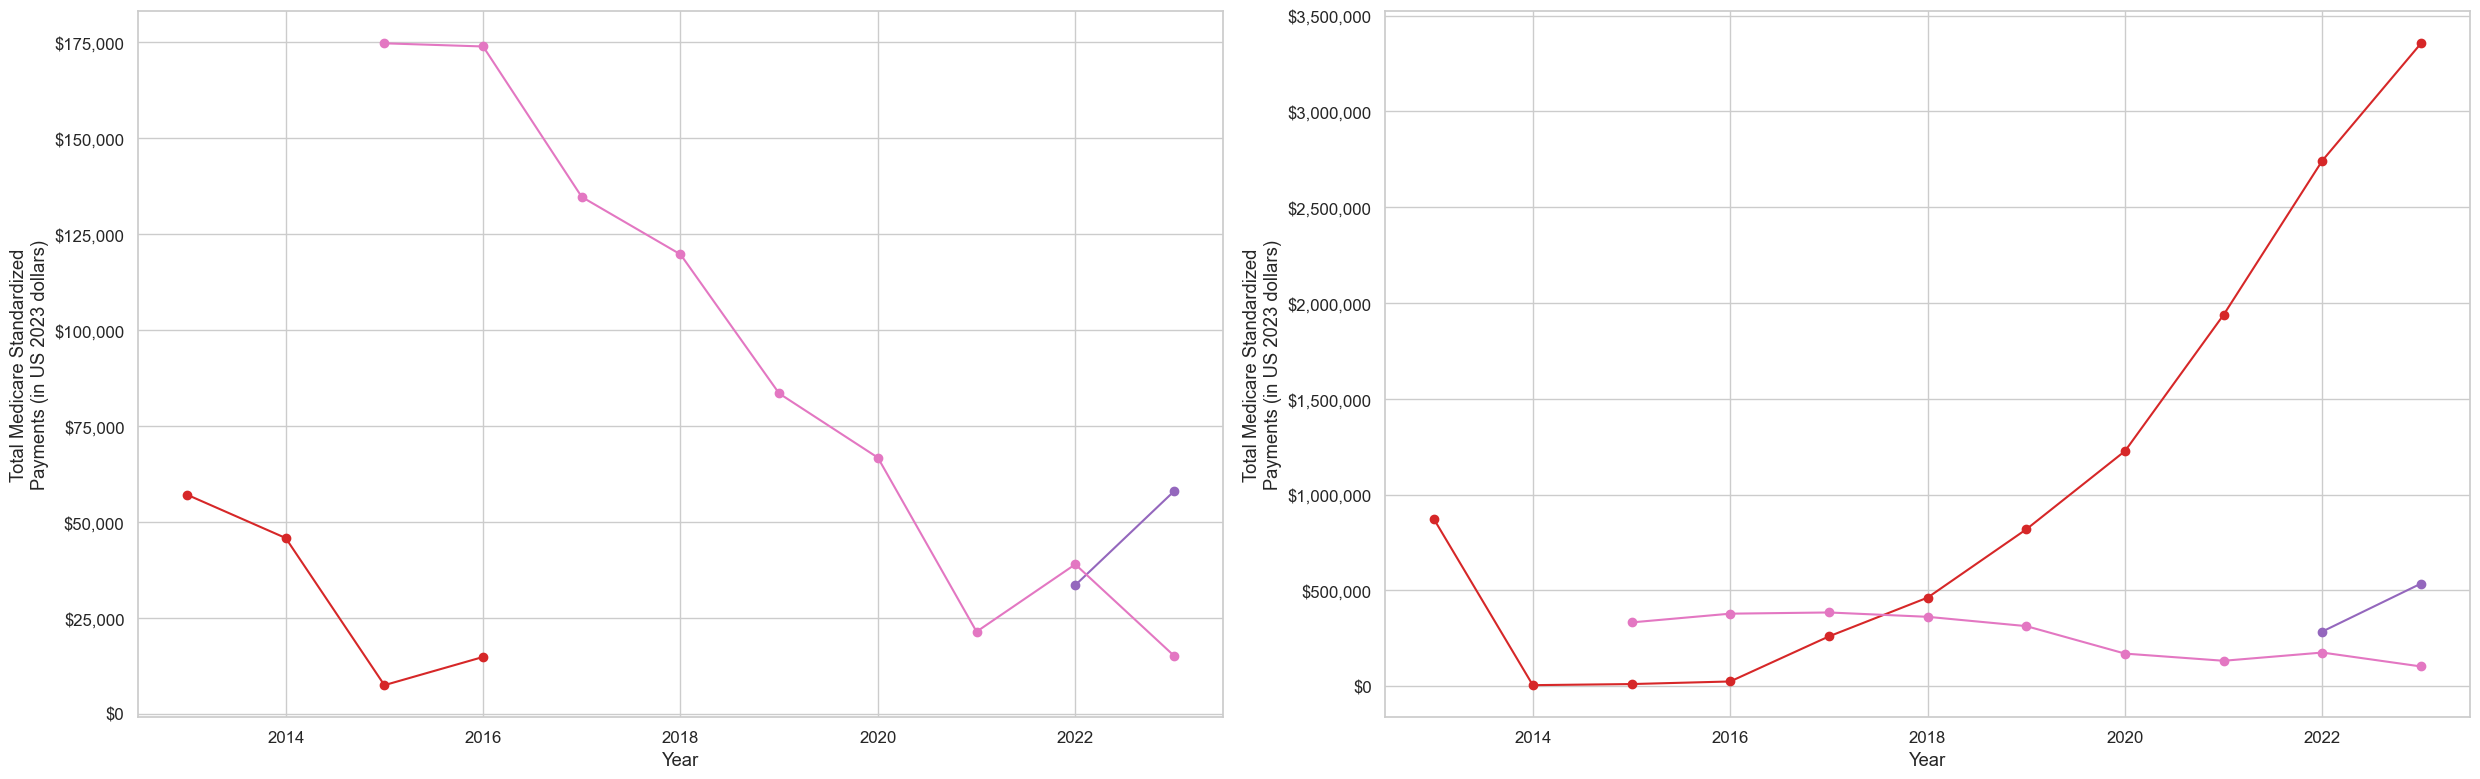

In [164]:
fig, axs = plt.subplots(1, 2, figsize=(25, 8)) 

for i, specialty in enumerate([util_2023_2013_adj_surg, util_2023_2013_adj_nonsurg]):
    grouped = specialty.groupby(groupby_key)
    p_num = 0
    
    for label, df in grouped:
        if label in ('other_spine_interventions', 'vertebral_augmentation', 'si_joint_rfa'):
            # Sort by year to ensure proper line plotting
            df_sorted = df.sort_values('year')
            
            x = df_sorted['year']
            y = df_sorted['Sum_Pymt_adj']
            axs[i].plot(x, y, label=label, marker='o', markersize=6, linestyle='-', color=colors[p_num])
        
        p_num += 1
    
    # axs[i].legend(title=groupby_key)
    axs[i].set_xlabel("Year")
    axs[i].set_ylabel("Total Medicare Standardized\nPayments (in US 2023 dollars)")
    # axs[i].set_title(f"Total Medicare Standardized Payment by Procedure Type ({specialty_name[i]})")

    axs[i].yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"${x:,.0f}"))

plt.tight_layout()

## Total Payment Growth Rate

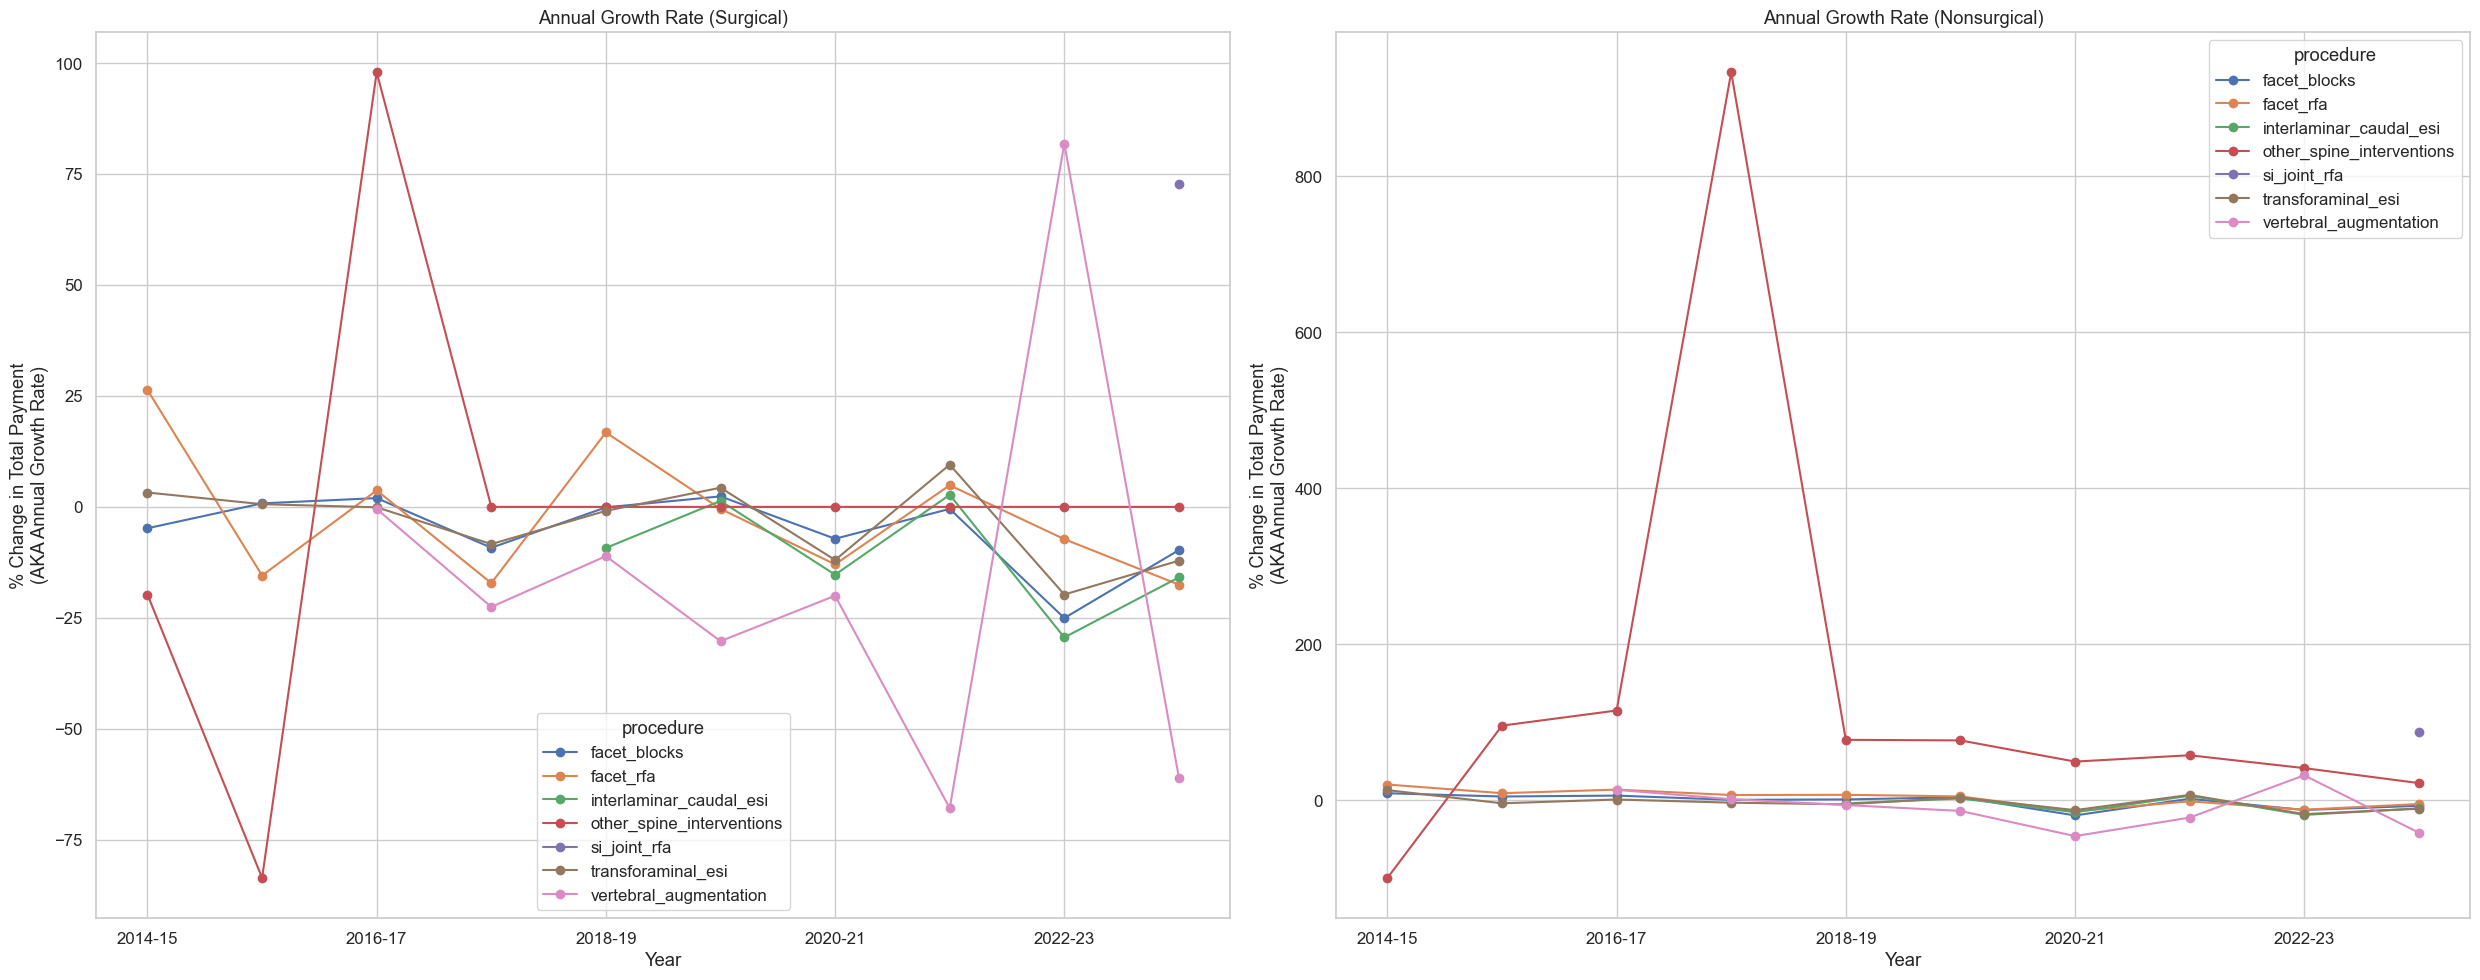

In [185]:
fig, axs = plt.subplots(1, 2, figsize=(25, 10)) 

aagr = {'Surgical': [], 'Nonsurgical': []}
aagr_no_interp = {'Surgical': [], 'Nonsurgical': []}
all_deltas = {'Surgical': [], 'Nonsurgical': []}

for i, specialty in enumerate([util_2023_2013_adj_surg, util_2023_2013_adj_nonsurg]):
    grouped = specialty.groupby(groupby_key)
    for label, df in grouped:
        # Sort by year to ensure proper line plotting
        df_sorted = df.sort_values('year')
        
        x = df_sorted['year'].tolist()
        y = df_sorted['Sum_Pymt_adj'].tolist()
    
        pairs = {x[i]: item for i, item in enumerate(y)}
    
        x_new = list(range(2013, 2024))
    
        y_new = [pairs[year] if year in pairs else np.nan for year in x_new]
        delta = pd.Series(y_new).interpolate().pct_change().to_numpy() * 100

        axs[i].plot(range(len(delta)), delta, label=label, marker='o', markersize=6, linestyle='-')

        # Use this to compute AAGR per procedure later
        aagr[specialty_name[i]].append([label, np.nanmean(delta), specialty_name[i]])

        # Compute a version of AAGR without interpolation
        delta_no_interp = pd.Series(y_new).pct_change().to_numpy() * 100
        aagr_no_interp[specialty_name[i]].append([label, np.nanmean(delta_no_interp), specialty_name[i]])

        # Use this to plot average growth rate across procedures later
        all_deltas[specialty_name[i]].append(delta)

    axs[i].legend(title=groupby_key)
    axs[i].set_xlabel("Year")
    axs[i].set_xticks([1, 3, 5, 7, 9])
    axs[i].set_xticklabels(['2014-15', '2016-17', '2018-19', '2020-21', '2022-23']),
    axs[i].set_ylabel("% Change in Total Payment\n(AKA Annual Growth Rate)")
    # axs[i].set_ylim([-75, 750])
    axs[i].set_title(f"Annual Growth Rate ({specialty_name[i]})")

plt.tight_layout()

In [169]:
pd.DataFrame(
    aagr['Surgical'] + aagr['Nonsurgical'], columns=['procedure', 'AAGR (%)', 'specialty']
).sort_values(by=['AAGR (%)']).to_csv("results/pain_total_pymt_aagr_by_procedure.csv", index=False)

In [184]:
aagr = {'Surgical': [], 'Nonsurgical': []}
aagr_no_interp = {'Surgical': [], 'Nonsurgical': []}
all_deltas = {'Surgical': [], 'Nonsurgical': []}

for i, specialty in enumerate([util_2023_2013_adj_surg_by_cpt, util_2023_2013_adj_nonsurg_by_cpt]):
    grouped = specialty.groupby('HCPCS_Cd')
    for label, df in grouped:
        # Sort by year to ensure proper line plotting
        df_sorted = df.sort_values('year')
        
        x = df_sorted['year'].tolist()
        y = df_sorted['Sum_Pymt_adj'].tolist()
    
        pairs = {x[i]: item for i, item in enumerate(y)}
    
        x_new = list(range(2013, 2024))
    
        y_new = [pairs[year] if year in pairs else np.nan for year in x_new]
        delta = pd.Series(y_new).interpolate().pct_change().to_numpy() * 100

        # Use this to compute AAGR per procedure later
        aagr[specialty_name[i]].append([label, np.nanmean(delta), specialty_name[i]])

        # Compute a version of AAGR without interpolation
        delta_no_interp = pd.Series(y_new).pct_change().to_numpy() * 100
        aagr_no_interp[specialty_name[i]].append([label, np.nanmean(delta_no_interp), specialty_name[i]])

        # Use this to plot average growth rate across procedures later
        all_deltas[specialty_name[i]].append(delta)

In [174]:
pd.DataFrame(
    aagr['Surgical'] + aagr['Nonsurgical'], columns=['cpt', 'AAGR (%)', 'specialty']
).sort_values(by=['AAGR (%)']).to_csv("results/pain_total_pymt_aagr_by_cpt_code.csv", index=False)

/var/folders/jv/hvl4bxhn45d10f4fq__lhlxm0000gn/T/ipykernel_57424/817045496.py:5: RuntimeWarning: Mean of empty slice
  aagr = np.nanmean(np.array(specialty), axis=0)


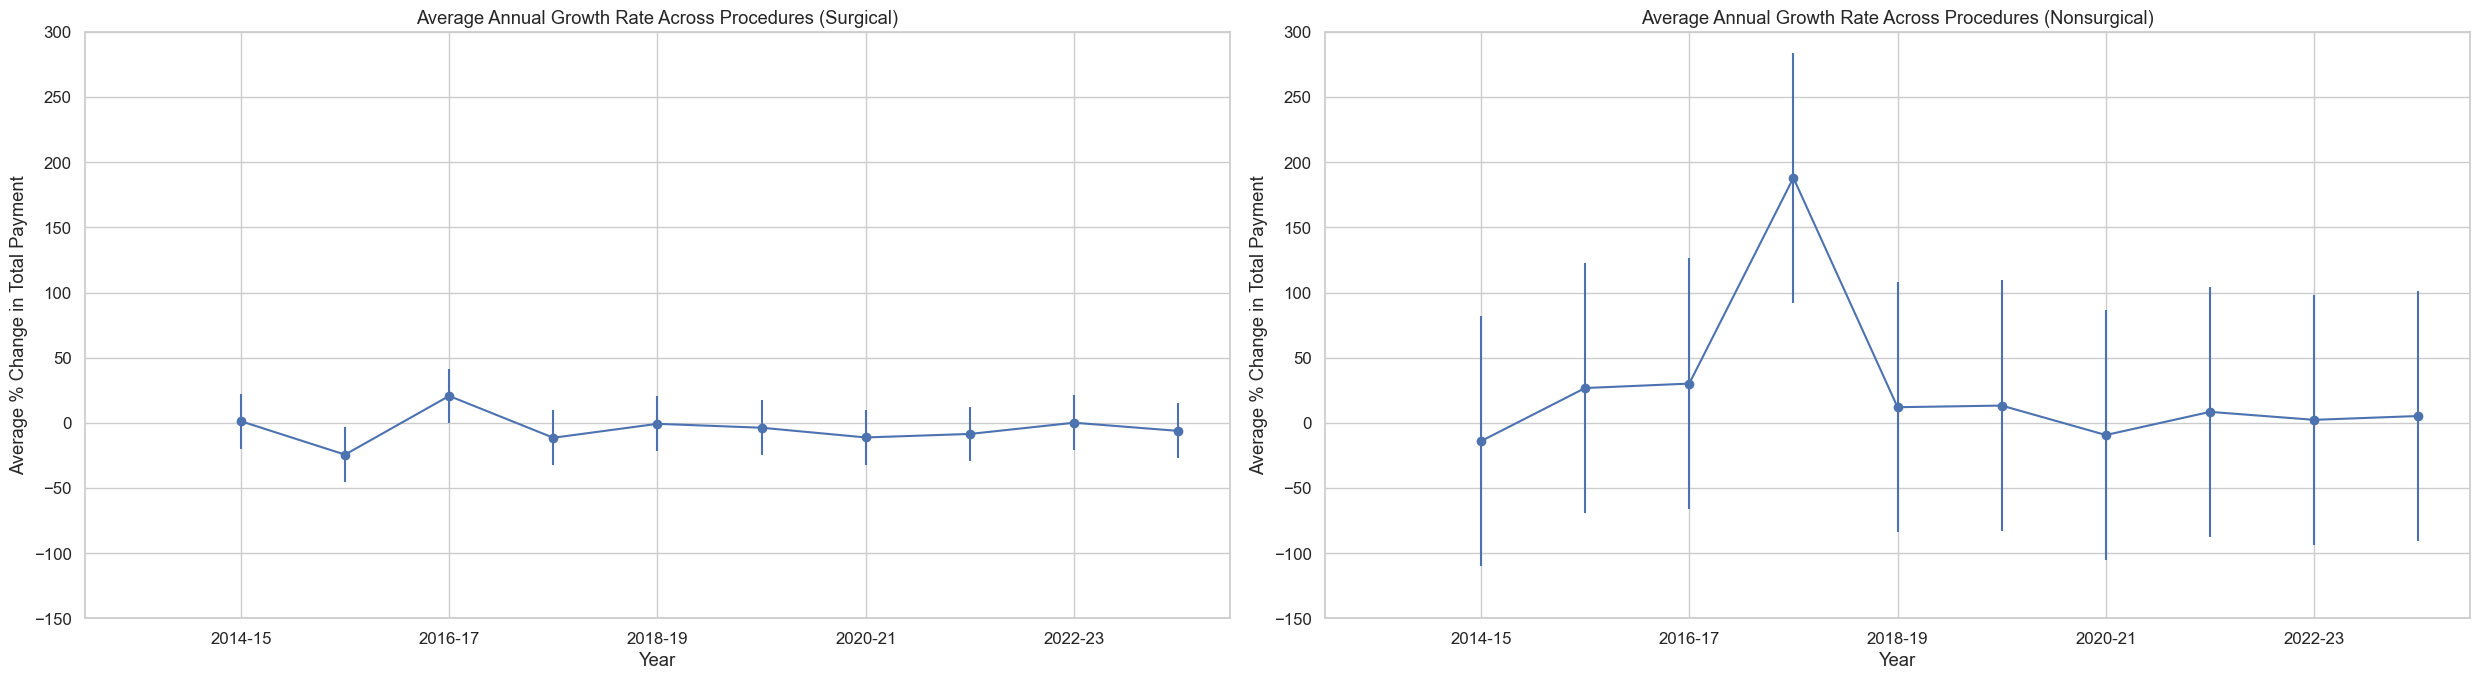

In [187]:
fig, axs = plt.subplots(1, 2, figsize=(25, 7)) 

i = 0
for key, specialty in all_deltas.items():
    aagr = np.nanmean(np.array(specialty), axis=0)
    sem = np.nanstd(np.array(specialty), ddof=1) / np.sqrt(len(specialty))
    
    ci_lower = aagr - 1.96 * sem
    ci_upper = aagr + 1.96 * sem
    
    # Compute error bars from CI bounds
    yerr = [aagr - ci_lower, ci_upper - aagr]

    axs[i].errorbar(range(len(aagr)), aagr, yerr=yerr,  marker='o', markersize=6, linestyle='-')

    axs[i].set_xlabel("Year")
    axs[i].set_xticks([1, 3, 5, 7, 9])
    axs[i].set_xticklabels(['2014-15', '2016-17', '2018-19', '2020-21', '2022-23']),
    axs[i].set_ylabel("Average % Change in Total Payment")
    axs[i].set_ylim([-150, 300])
    axs[i].set_title(f"Average Annual Growth Rate Across Procedures ({specialty_name[i]})")

    i += 1

plt.tight_layout()

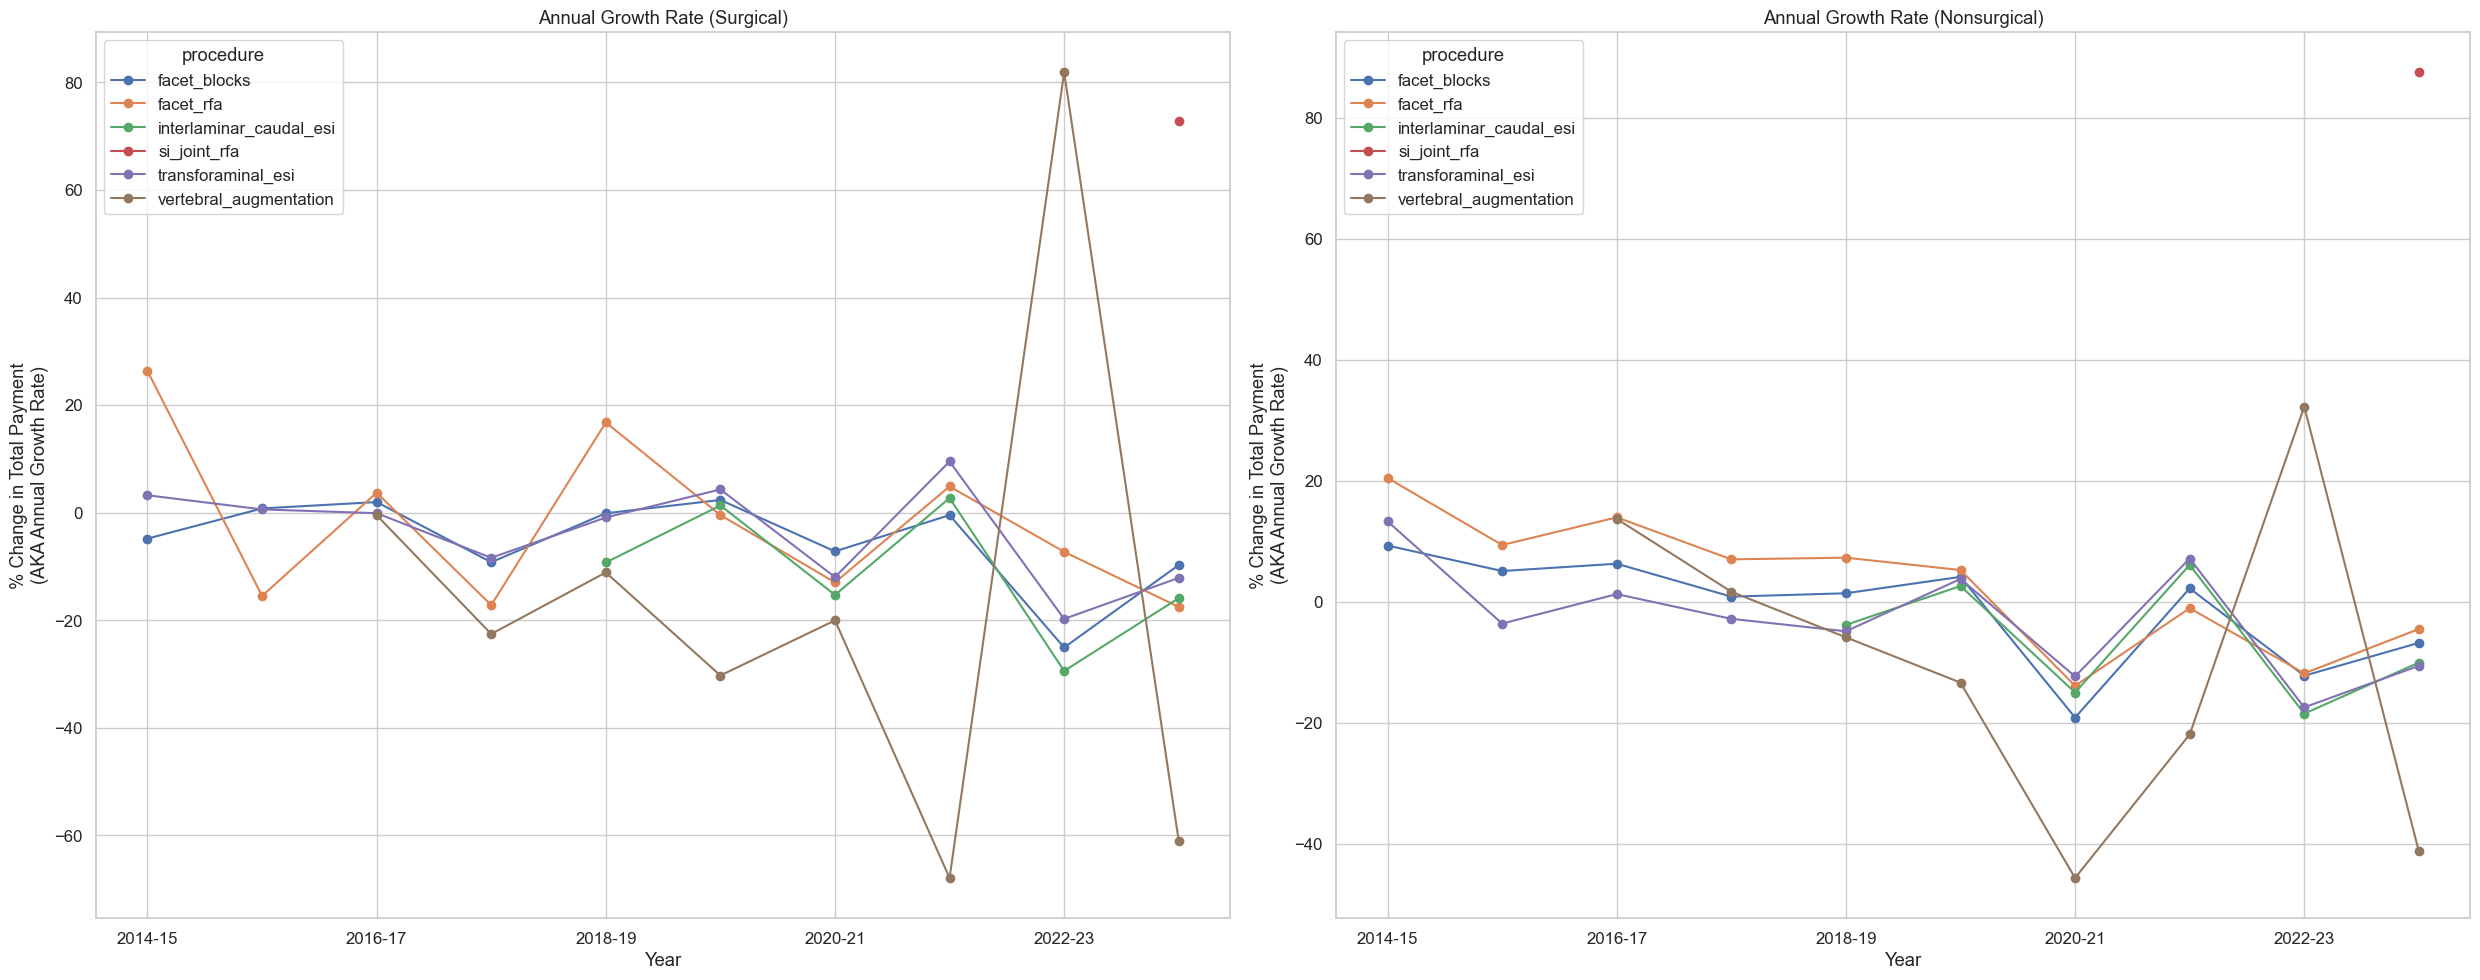

In [181]:
fig, axs = plt.subplots(1, 2, figsize=(25, 10)) 

aagr = {'Surgical': [], 'Nonsurgical': []}
aagr_no_interp = {'Surgical': [], 'Nonsurgical': []}
all_deltas = {'Surgical': [], 'Nonsurgical': []}

for i, specialty in enumerate([util_2023_2013_adj_surg, util_2023_2013_adj_nonsurg]):
    grouped = specialty.groupby(groupby_key)
    for label, df in grouped:
        if label == "other_spine_interventions":
            continue
        # Sort by year to ensure proper line plotting
        df_sorted = df.sort_values('year')
        
        x = df_sorted['year'].tolist()
        y = df_sorted['Sum_Pymt_adj'].tolist()
    
        pairs = {x[i]: item for i, item in enumerate(y)}
    
        x_new = list(range(2013, 2024))
    
        y_new = [pairs[year] if year in pairs else np.nan for year in x_new]
        delta = pd.Series(y_new).interpolate().pct_change().to_numpy() * 100

        axs[i].plot(range(len(delta)), delta, label=label, marker='o', markersize=6, linestyle='-')

        # Use this to compute AAGR per procedure later
        aagr[specialty_name[i]].append([label, np.nanmean(delta), specialty_name[i]])

        # Compute a version of AAGR without interpolation
        delta_no_interp = pd.Series(y_new).pct_change().to_numpy() * 100
        aagr_no_interp[specialty_name[i]].append([label, np.nanmean(delta_no_interp), specialty_name[i]])

        # Use this to plot average growth rate across procedures later
        all_deltas[specialty_name[i]].append(delta)

    axs[i].legend(title=groupby_key)
    axs[i].set_xlabel("Year")
    axs[i].set_xticks([1, 3, 5, 7, 9])
    axs[i].set_xticklabels(['2014-15', '2016-17', '2018-19', '2020-21', '2022-23']),
    axs[i].set_ylabel("% Change in Total Payment\n(AKA Annual Growth Rate)")
    # axs[i].set_ylim([-75, 750])
    axs[i].set_title(f"Annual Growth Rate ({specialty_name[i]})")

plt.tight_layout()

/var/folders/jv/hvl4bxhn45d10f4fq__lhlxm0000gn/T/ipykernel_57424/1072135359.py:5: RuntimeWarning: Mean of empty slice
  aagr = np.nanmean(np.array(specialty), axis=0)


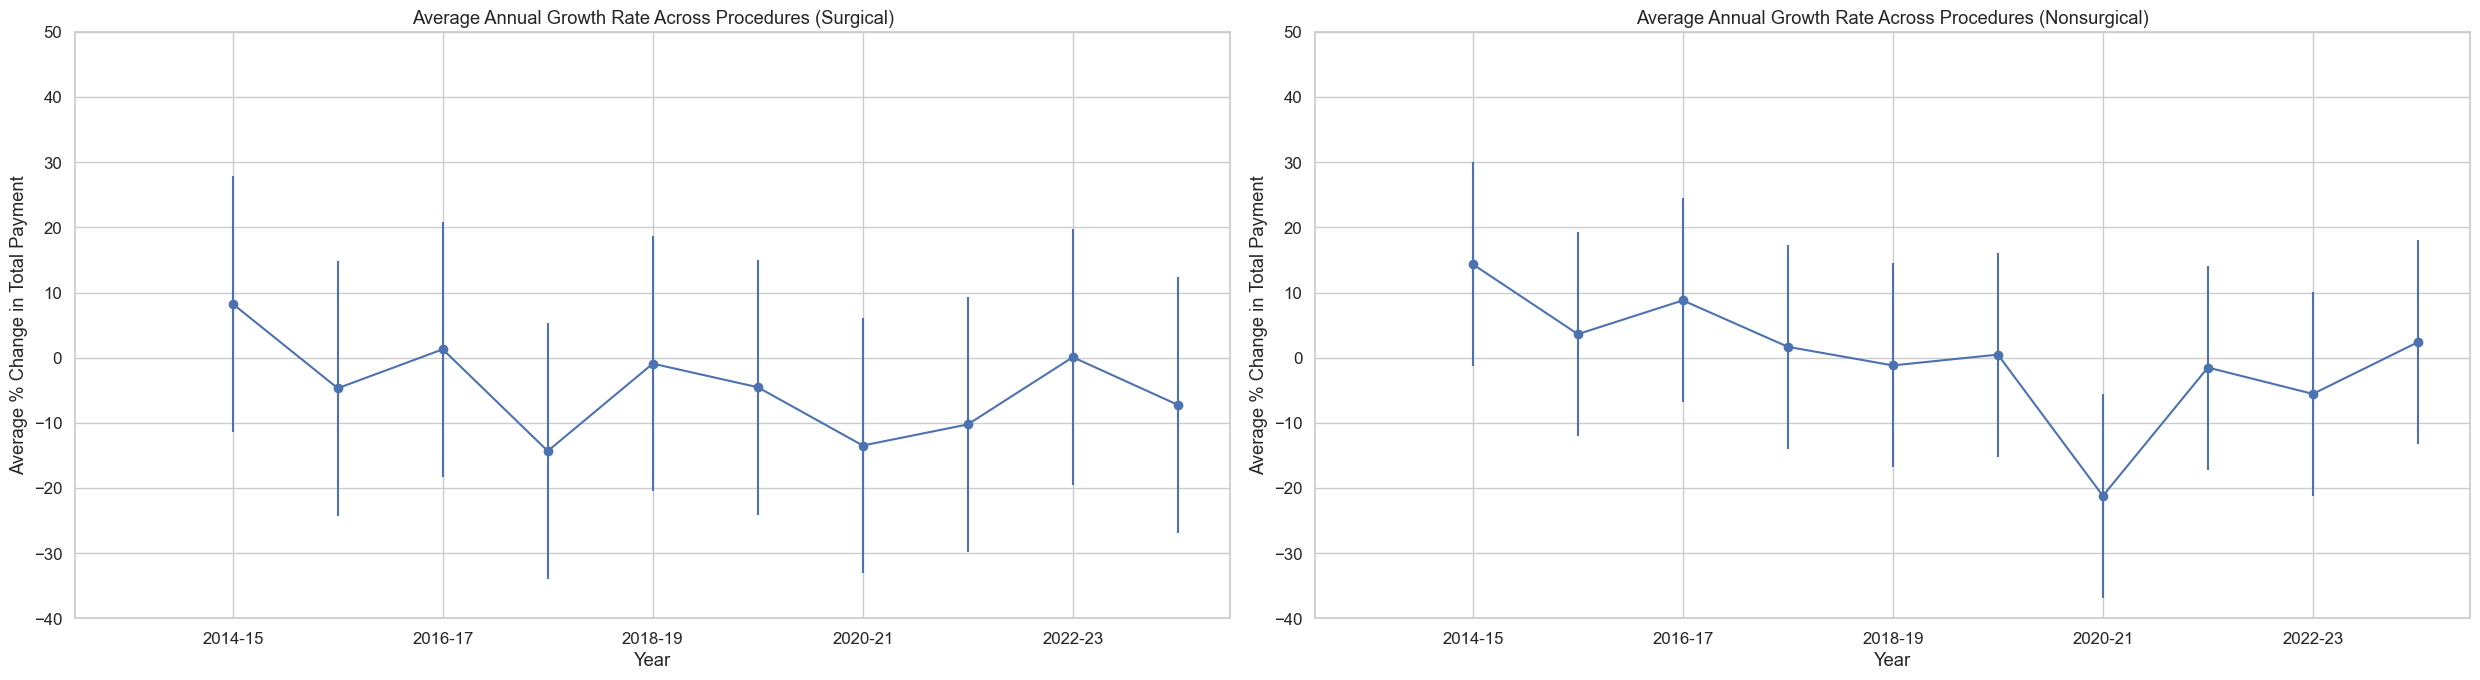

In [182]:
fig, axs = plt.subplots(1, 2, figsize=(25, 7)) 

i = 0
for key, specialty in all_deltas.items():
    aagr = np.nanmean(np.array(specialty), axis=0)
    sem = np.nanstd(np.array(specialty), ddof=1) / np.sqrt(len(specialty))
    
    ci_lower = aagr - 1.96 * sem
    ci_upper = aagr + 1.96 * sem
    
    # Compute error bars from CI bounds
    yerr = [aagr - ci_lower, ci_upper - aagr]

    axs[i].errorbar(range(len(aagr)), aagr, yerr=yerr,  marker='o', markersize=6, linestyle='-')

    axs[i].set_xlabel("Year")
    axs[i].set_xticks([1, 3, 5, 7, 9])
    axs[i].set_xticklabels(['2014-15', '2016-17', '2018-19', '2020-21', '2022-23']),
    axs[i].set_ylabel("Average % Change in Total Payment")
    axs[i].set_ylim([-40, 50])
    axs[i].set_title(f"Average Annual Growth Rate Across Procedures ({specialty_name[i]})")

    i += 1

plt.tight_layout()